# **Analyzing the Effects of Economic Factors on Cryptocurrency**
## Group 7
### Data 603
**Mariam Isayan**  
**William Gu**  
**Sitaram Suhas Chandu**



**Last update:** 18 November 2025

**Notes**  
Pyspark v.3.5.1

Runtime Google Colab
*   Data cleaning T4 GPU
*   Model training CPU



---



## Install Pyspark and dependencies

In [ ]:
!pip -q install pyspark==3.5.1 pandas requests tqdm pyarrow humanize


In [ ]:
!apt-get -y -qq update
!apt-get -y -qq install openjdk-17-jdk-headless

import os, sys
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

!java -version

!pip -q install --upgrade pip
!pip -q install pyspark==3.5.1


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
openjdk version "17.0.16" 2025-07-15
OpenJDK Runtime Environment (build 17.0.16+8-Ubuntu-0ubuntu122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.16+8-Ubuntu-0ubuntu122.04.1, mixed mode, sharing)


Initialize Spark session

In [ ]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("local-binance-fred")
         .config("spark.sql.session.timeZone","UTC")
         .config("spark.driver.memory", "2g")
         .getOrCreate())
spark

# Step 1: Data cleaning

## Download per minute data 2020-2025
### Core
* BTCUSDT
* ETHUSDT
* DOGEUSDT
### USDT
* USDTUSD
* USDTBUSD
* USD1USDT
* USDTUSDC

In [ ]:
import os, io, zipfile, requests
from pathlib import Path
from tqdm import tqdm

BASE = "https://data.binance.vision/data/spot/monthly/klines"
INTERVAL = "1m"
YEARS = list(range(2020, 2026))
CORE = ["BTCUSDT","ETHUSDT","DOGEUSDT"]
USDT_CANDIDATES = ["USDTUSD","USDTBUSD","USD1USDT","USDTUSDC"]

RAW_DIR = Path("/content/binance"); RAW_DIR.mkdir(parents=True, exist_ok=True)

def dl_month(sym, y, m, out_dir):
    url = f"{BASE}/{sym}/{INTERVAL}/{sym}-{INTERVAL}-{y}-{m:02d}.zip"
    r = requests.get(url, timeout=60)
    if r.status_code != 200: return False
    zipfile.ZipFile(io.BytesIO(r.content)).extractall(out_dir); return True

for sym in CORE:
    (RAW_DIR/sym).mkdir(parents=True, exist_ok=True)
    for y in YEARS:
        for m in tqdm(range(1,13), desc=f"{sym}-{y}"): dl_month(sym,y,m,RAW_DIR/sym)

for y in YEARS:
    for m in tqdm(range(1,13), desc=f"USDT-{y}"):
        for cand in USDT_CANDIDATES:
            (RAW_DIR/cand).mkdir(parents=True, exist_ok=True)
            if dl_month(cand,y,m,RAW_DIR/cand): break


USDT-2025: 100%|██████████| 12/12 [00:16<00:00,  1.36s/it]


In [ ]:
import glob
len(glob.glob("/content/binance/*/*.csv"))


216

## Create Spark schema and load in dataframe

In [ ]:
from pyspark.sql import functions as F, Window
from pyspark.sql.types import StructType,StructField,StringType,LongType,DoubleType
from pyspark.sql.functions import col, lit, input_file_name, regexp_extract

schema = (StructType()
    .add("open_time", LongType()).add("open", StringType()).add("high", StringType())
    .add("low", StringType()).add("close", StringType()).add("volume", StringType())
    .add("close_time", LongType()).add("quote_asset_volume", StringType())
    .add("number_of_trades", StringType()).add("taker_buy_base", StringType())
    .add("taker_buy_quote", StringType()).add("ignore", StringType()))

df_raw = (spark.read.format("csv").option("header","false").schema(schema)
          .load("/content/binance/*/*.csv")
          .withColumn("file", input_file_name()))

df_raw = df_raw.withColumn("src_symbol",
            regexp_extract(col("file"), r"/([A-Z0-9]+)-1m-\d{4}-\d{2}\.csv$", 1))

df_raw = df_raw.withColumn(
    "symbol",
    F.when(col("src_symbol").isin("BTCUSDT","ETHUSDT","DOGEUSDT"), col("src_symbol"))
     .otherwise(lit("USTT_STABLEUSD"))
)

for c in ["open","high","low","close","volume","quote_asset_volume","taker_buy_base","taker_buy_quote"]:
    df_raw = df_raw.withColumn(c, col(c).cast("double"))
df_raw = df_raw.withColumn("number_of_trades", col("number_of_trades").cast("long"))

SAFE_MIN_MS, SAFE_MAX_MS = 1577836800000, 1767225600000
df_raw = df_raw.filter(col("open_time").between(SAFE_MIN_MS, SAFE_MAX_MS)
                       & col("close_time").between(SAFE_MIN_MS, SAFE_MAX_MS))


In [ ]:
from pyspark.sql.functions import to_timestamp, from_unixtime, percentile_approx

df = (df_raw
      .withColumn("ts_open",  to_timestamp(from_unixtime((col("open_time")/1000).cast("long"))))
      .withColumn("ts_close", to_timestamp(from_unixtime((col("close_time")/1000).cast("long")))))

df = (df.dropna(subset=["ts_open","open","high","low","close","volume"])
        .filter((col("open")>0)&(col("high")>0)&(col("low")>0)&(col("close")>0)&(col("volume")>=0))
        .filter((col("high")>=col("low"))&(col("high")>=col("open"))&(col("high")>=col("close"))&
                (col("low")<=col("open")) &(col("low")<=col("close"))))

w = Window.partitionBy("symbol","open_time").orderBy(col("open_time"))
df = df.withColumn("rn", F.row_number().over(w)).filter(col("rn")==1).drop("rn")

bounds = (df.groupBy("symbol")
            .agg(percentile_approx("close",0.01).alias("p01"),
                 percentile_approx("close",0.99).alias("p99")))
df_1m = (df.join(bounds,"symbol")
           .filter((col("close")>=col("p01")) & (col("close")<=col("p99")))
           .drop("p01","p99")).cache()

df_1m.count()


7727609

### Resample daily OHLCV data

In [ ]:
from pyspark.sql.functions import date_trunc, min as smin, max as smax, sum as ssum, first

d = df_1m.withColumn("day", date_trunc("DAY", col("ts_open")))
rng = (d.groupBy("symbol","day")
         .agg(smin("ts_open").alias("min_ts"),
              smax("ts_open").alias("max_ts"),
              ssum("volume").alias("volume"),
              ssum("quote_asset_volume").alias("quote_asset_volume"),
              ssum("number_of_trades").alias("trades"),
              smax("high").alias("high"),
              smin("low").alias("low")))

open_rows = (d.alias("d_open").join(rng.alias("rng_open").select("symbol","day","min_ts"),
                    (col("d_open.symbol")==col("rng_open.symbol")) & (col("d_open.day")==col("rng_open.day")) & (col("d_open.ts_open")==col("rng_open.min_ts")),"inner")
               .select(col("d_open.symbol").alias("s_o"), col("d_open.day").alias("d_o"), col("d_open.open").alias("open")))
close_rows = (d.alias("d_close").join(rng.alias("rng_close").select("symbol","day","max_ts"),
                    (col("d_close.symbol")==col("rng_close.symbol")) & (col("d_close.day")==col("rng_close.day")) & (col("d_close.ts_open")==col("rng_close.max_ts")),"inner")
               .select(col("d_close.symbol").alias("s_c"), col("d_close.day").alias("d_c"), col("d_close.close").alias("close")))


daily = (rng.alias("rng_daily").join(open_rows.alias("open_rows"), (col("rng_daily.symbol")==col("open_rows.s_o"))&(col("rng_daily.day")==col("open_rows.d_o")))
            .join(close_rows.alias("close_rows"),(col("rng_daily.symbol")==col("close_rows.s_c"))&(col("rng_daily.day")==col("close_rows.d_c")))
            .select(col("rng_daily.symbol").alias("symbol"), col("rng_daily.day"),
                    col("open_rows.open").alias("open"), col("rng_daily.high"), col("rng_daily.low"), col("close_rows.close").alias("close"),
                    col("rng_daily.volume"), col("rng_daily.quote_asset_volume"), col("rng_daily.trades"))
            .orderBy("symbol","day")).cache()

daily.count()

5415

### Add FRED API daily metrics


*   CPIAUCSL
*   GDPC1
*   CPI



In [ ]:
import pandas as pd
from pyspark.sql.types import StructType,StructField,TimestampType,DoubleType
from pyspark.sql.functions import last_day, date_trunc as dt, year

cpi_pd = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL")
cpi_pd.columns=["DATE","CPI"]; cpi_pd["DATE"]=pd.to_datetime(cpi_pd["DATE"]); cpi_pd=cpi_pd.dropna()

gdp_pd = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDPC1")
gdp_pd.columns=["DATE","GDPC1"]; gdp_pd["DATE"]=pd.to_datetime(gdp_pd["DATE"]); gdp_pd=gdp_pd.dropna()

cpi_s = (spark.createDataFrame(cpi_pd, StructType([
            StructField("DATE",TimestampType(),True),StructField("CPI",DoubleType(),True)]))
         .withColumn("month_end", last_day(col("DATE"))).select("month_end","CPI"))

gdp_s = (spark.createDataFrame(gdp_pd, StructType([
            StructField("DATE",TimestampType(),True),StructField("GDPC1",DoubleType(),True)]))
         .withColumn("quarter_end", dt("QUARTER", col("DATE"))).select("quarter_end","GDPC1"))

daily_keys = (daily.withColumn("month_end", last_day(col("day")))
                    .withColumn("quarter_end", dt("QUARTER", col("day"))))

daily_with_macro = (daily_keys.join(cpi_s, "month_end", "left")
                               .join(gdp_s, "quarter_end", "left")).cache()

daily_with_macro.count()


5415

### Print top rows for each symbol

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, input_file_name, regexp_extract


base_path = "/content/binance"

kline_schema = "open_time LONG, open STRING, high STRING, low STRING, close STRING, volume STRING, close_time LONG, quote_asset_volume STRING, number_of_trades STRING, taker_buy_base STRING, taker_buy_quote STRING, ignore STRING"

crypto_raw = (spark.read
              .schema(kline_schema)
              .csv(f"{base_path}/*/*.csv")
              .withColumn("file", input_file_name()))

crypto_raw = crypto_raw.withColumn(
    "src_symbol",
    regexp_extract(col("file"), r"/([A-Z0-9]+)-1m-\d{4}-\d{2}\.csv$", 1)
)

crypto_raw = crypto_raw.withColumn(
    "symbol",
    F.when(col("src_symbol").isin("BTCUSDT","ETHUSDT","DOGEUSDT"), col("src_symbol"))
     .otherwise(F.lit("USDT_STABLEUSD"))
)

print("=== Attributes (columns) in crypto CSVs ===")
print(crypto_raw.columns)

print("\n=== BTC (raw) – first 5 rows ===")
(crypto_raw.filter(col("symbol")=="BTCUSDT")
           .show(5, truncate=False))

print("\n=== ETH (raw) – first 5 rows ===")
(crypto_raw.filter(col("symbol")=="ETHUSDT")
           .show(5, truncate=False))

print("\n=== DOGE (raw) – first 5 rows ===")
(crypto_raw.filter(col("symbol")=="DOGEUSDT")
           .show(5, truncate=False))

print("\n=== Tether (raw, unified) – first 5 rows ===")
(crypto_raw.filter(col("symbol")=="USDT_STABLEUSD")
           .show(5, truncate=False))


=== Attributes (columns) in crypto CSVs ===
['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base', 'taker_buy_quote', 'ignore', 'file', 'src_symbol', 'symbol']

=== BTC (raw) – first 5 rows ===
+----------------+---------------+---------------+---------------+---------------+-----------+----------------+------------------+----------------+--------------+----------------+------+------------------------------------------------------+----------+-------+
|open_time       |open           |high           |low            |close          |volume     |close_time      |quote_asset_volume|number_of_trades|taker_buy_base|taker_buy_quote |ignore|file                                                  |src_symbol|symbol |
+----------------+---------------+---------------+---------------+---------------+-----------+----------------+------------------+----------------+--------------+----------------+------+-----------------------

## Prepare crypto_clean for time_series and model training

In [ ]:
from pyspark.sql.functions import to_timestamp, from_unixtime
from pyspark.sql.window import Window

num_cols = ["open","high","low","close","volume",
            "quote_asset_volume","taker_buy_base","taker_buy_quote"]
crypto = crypto_raw
for c in num_cols:
    crypto = crypto.withColumn(c, col(c).cast("double"))
crypto = crypto.withColumn("number_of_trades", col("number_of_trades").cast("long"))

SAFE_MIN_MS = 1577836800000
SAFE_MAX_MS = 1767225600000
crypto = crypto.filter(
    col("open_time").between(SAFE_MIN_MS, SAFE_MAX_MS) &
    col("close_time").between(SAFE_MIN_MS, SAFE_MAX_MS)
)

crypto = (crypto
          .withColumn("ts_open",  to_timestamp(from_unixtime((col("open_time")/1000).cast("long"))))
          .withColumn("ts_close", to_timestamp(from_unixtime((col("close_time")/1000).cast("long")))))

crypto = (crypto.dropna(subset=["ts_open","open","high","low","close","volume"])
          .filter((col("open")>0)&(col("high")>0)&(col("low")>0)&(col("close")>0)&(col("volume")>=0))
          .filter((col("high")>=col("low")) &
                  (col("high")>=col("open")) & (col("high")>=col("close")) &
                  (col("low")<=col("open"))  & (col("low")<=col("close"))))

w = Window.partitionBy("symbol","open_time").orderBy(col("open_time"))
crypto = (crypto
          .withColumn("rn", F.row_number().over(w))
          .filter(col("rn")==1)
          .drop("rn"))

bounds = (crypto.groupBy("symbol")
          .agg(F.percentile_approx("close",0.01).alias("p01"),
               F.percentile_approx("close",0.99).alias("p99")))
crypto_clean = (crypto.join(bounds,"symbol")
                      .filter((col("close")>=col("p01")) & (col("close")<=col("p99")))
                      .drop("p01","p99")
                      .cache())

print("\n=== BTC (clean) – first 5 rows ===")
(crypto_clean.filter(col("symbol")=="BTCUSDT")
             .select("symbol","ts_open","open","high","low","close","volume","number_of_trades")
             .orderBy("ts_open")
             .show(5, truncate=False))

print("\n=== ETH (clean) – first 5 rows ===")
(crypto_clean.filter(col("symbol")=="ETHUSDT")
             .select("symbol","ts_open","open","high","low","close","volume","number_of_trades")
             .orderBy("ts_open")
             .show(5, truncate=False))

print("\n=== DOGE (clean) – first 5 rows ===")
(crypto_clean.filter(col("symbol")=="DOGEUSDT")
             .select("symbol","ts_open","open","high","low","close","volume","number_of_trades")
             .orderBy("ts_open")
             .show(5, truncate=False))

print("\n=== Tether (clean) – first 5 rows ===")
(crypto_clean.filter(col("symbol")=="USDT_STABLEUSD")
             .select("symbol","ts_open","open","high","low","close","volume","number_of_trades")
             .orderBy("ts_open")
             .show(5, truncate=False))



=== BTC (clean) – first 5 rows ===
+-------+-------------------+-------+-------+-------+-------+---------+----------------+
|symbol |ts_open            |open   |high   |low    |close  |volume   |number_of_trades|
+-------+-------------------+-------+-------+-------+-------+---------+----------------+
|BTCUSDT|2020-01-01 00:00:00|7195.24|7196.25|7183.14|7186.68|51.642812|493             |
|BTCUSDT|2020-01-01 00:01:00|7187.67|7188.06|7182.2 |7184.03|7.248148 |135             |
|BTCUSDT|2020-01-01 00:02:00|7184.41|7184.71|7180.26|7182.43|11.681677|202             |
|BTCUSDT|2020-01-01 00:03:00|7183.83|7188.94|7182.49|7185.94|10.025391|136             |
|BTCUSDT|2020-01-01 00:04:00|7185.54|7185.54|7178.64|7179.78|14.911105|161             |
+-------+-------------------+-------+-------+-------+-------+---------+----------------+
only showing top 5 rows


=== ETH (clean) – first 5 rows ===
+-------+-------------------+------+------+------+------+----------+----------------+
|symbol |ts_open

### Harmonize with CPI data

In [ ]:
import pandas as pd
from pyspark.sql.types import StructType,StructField,TimestampType,DoubleType
from pyspark.sql.functions import last_day, date_trunc as dt

cpi_pd = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL")
cpi_pd.columns = ["DATE","CPI"]
cpi_pd["DATE"] = pd.to_datetime(cpi_pd["DATE"], errors="coerce")

cpi_s = spark.createDataFrame(
    cpi_pd,
    schema=StructType([
        StructField("DATE", TimestampType(), True),
        StructField("CPI",  DoubleType(),   True)
    ])
)

print("\n=== CPI (raw) columns ===")
print(cpi_s.columns)

print("\n=== CPI (raw) – first 5 ===")
cpi_s.orderBy("DATE").show(5, truncate=False)

total_cpi = cpi_s.count()
print(f"\nCPI total rows: {total_cpi}")
print("DATE nulls:", cpi_s.filter(col("DATE").isNull()).count())
print("CPI nulls:", cpi_s.filter(col("CPI").isNull()).count())

cpi_clean = (cpi_s
             .dropna(subset=["DATE","CPI"])
             .dropDuplicates(["DATE"])
             .filter((col("DATE") >= "2019-01-01") & (col("DATE") < "2026-12-31"))
             .withColumn("month_end", last_day(col("DATE"))))

print("\n=== CPI (clean) – first 5 ===")
cpi_clean.orderBy("DATE").show(5, truncate=False)



=== CPI (raw) columns ===
['DATE', 'CPI']

=== CPI (raw) – first 5 ===
+-------------------+-----+
|DATE               |CPI  |
+-------------------+-----+
|1947-01-01 00:00:00|21.48|
|1947-02-01 00:00:00|21.62|
|1947-03-01 00:00:00|22.0 |
|1947-04-01 00:00:00|22.0 |
|1947-05-01 00:00:00|21.95|
+-------------------+-----+
only showing top 5 rows


CPI total rows: 945
DATE nulls: 0
CPI nulls: 0

=== CPI (clean) – first 5 ===
+-------------------+-------+----------+
|DATE               |CPI    |month_end |
+-------------------+-------+----------+
|2019-01-01 00:00:00|252.561|2019-01-31|
|2019-02-01 00:00:00|253.319|2019-02-28|
|2019-03-01 00:00:00|254.277|2019-03-31|
|2019-04-01 00:00:00|255.233|2019-04-30|
|2019-05-01 00:00:00|255.296|2019-05-31|
+-------------------+-------+----------+
only showing top 5 rows



### Harmonize with GDP data

In [ ]:
gdp_pd = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDPC1")
gdp_pd.columns = ["DATE","GDPC1"]
gdp_pd["DATE"] = pd.to_datetime(gdp_pd["DATE"], errors="coerce")

gdp_s = spark.createDataFrame(
    gdp_pd,
    schema=StructType([
        StructField("DATE", TimestampType(), True),
        StructField("GDPC1", DoubleType(),  True)
    ])
)

print("\n=== GDP (raw) columns ===")
print(gdp_s.columns)

print("\n=== GDP (raw) – first 5 ===")
gdp_s.orderBy("DATE").show(5, truncate=False)

total_gdp = gdp_s.count()
print(f"\nGDP total rows: {total_gdp}")
print("DATE nulls:", gdp_s.filter(col("DATE").isNull()).count())
print("GDPC1 nulls:", gdp_s.filter(col("GDPC1").isNull()).count())

gdp_clean = (gdp_s
             .dropna(subset=["DATE","GDPC1"])
             .dropDuplicates(["DATE"])
             .filter((col("DATE") >= "2018-01-01") & (col("DATE") < "2026-12-31"))
             .withColumn("quarter_end", dt("QUARTER", col("DATE"))))

print("\n=== GDP (clean) – first 5 ===")
gdp_clean.orderBy("DATE").show(5, truncate=False)



=== GDP (raw) columns ===
['DATE', 'GDPC1']

=== GDP (raw) – first 5 ===
+-------------------+--------+
|DATE               |GDPC1   |
+-------------------+--------+
|1947-01-01 00:00:00|2182.681|
|1947-04-01 00:00:00|2176.892|
|1947-07-01 00:00:00|2172.432|
|1947-10-01 00:00:00|2206.452|
|1948-01-01 00:00:00|2239.682|
+-------------------+--------+
only showing top 5 rows


GDP total rows: 314
DATE nulls: 0
GDPC1 nulls: 0

=== GDP (clean) – first 5 ===
+-------------------+---------+-------------------+
|DATE               |GDPC1    |quarter_end        |
+-------------------+---------+-------------------+
|2018-01-01 00:00:00|20044.077|2018-01-01 00:00:00|
|2018-04-01 00:00:00|20150.476|2018-04-01 00:00:00|
|2018-07-01 00:00:00|20276.154|2018-07-01 00:00:00|
|2018-10-01 00:00:00|20304.874|2018-10-01 00:00:00|
|2019-01-01 00:00:00|20431.641|2019-01-01 00:00:00|
+-------------------+---------+-------------------+
only showing top 5 rows



### Aggregate

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, date_trunc, min as smin, max as smax, sum as ssum

d = crypto_clean.withColumn("day", date_trunc("DAY", col("ts_open")))

rng = (d.groupBy("symbol","day")
         .agg(
             smin("ts_open").alias("min_ts"),
             smax("ts_open").alias("max_ts"),
             ssum("volume").alias("volume"),
             ssum("quote_asset_volume").alias("quote_asset_volume"),
             ssum("number_of_trades").alias("trades"),
             smax("high").alias("high"),
             smin("low").alias("low")
         ))

open_rows = (d.alias("d_open").join(rng.select("symbol","day","min_ts").alias("rng_open"),
                    on=[col("d_open.symbol")==col("rng_open.symbol"), col("d_open.day")==col("rng_open.day"), col("d_open.ts_open")==col("rng_open.min_ts")], how="inner")
               .select(col("d_open.symbol").alias("s_o"), col("d_open.day").alias("d_o"), col("d_open.open").alias("open")))
close_rows = (d.alias("d_close").join(rng.select("symbol","day","max_ts").alias("rng_close"),
                    on=[col("d_close.symbol")==col("rng_close.symbol"), col("d_close.day")==col("rng_close.day"), col("d_close.ts_open")==col("rng_close.max_ts")], how="inner")
               .select(col("d_close.symbol").alias("s_c"), col("d_close.day").alias("d_c"), col("d_close.close").alias("close")))

daily = (rng.alias("rng_daily")
         .join(open_rows.alias("open_rows"), (col("rng_daily.symbol")==col("open_rows.s_o"))&(col("rng_daily.day")==col("open_rows.d_o")), "left")
         .join(close_rows.alias("close_rows"),(col("rng_daily.symbol")==col("close_rows.s_c"))&(col("rng_daily.day")==col("close_rows.d_c")), "left")
         .select(col("rng_daily.symbol").alias("symbol"), col("rng_daily.day"),
                 col("open_rows.open").alias("open"), col("rng_daily.high"), col("rng_daily.low"), col("close_rows.close").alias("close"),
                 col("rng_daily.volume"), col("rng_daily.quote_asset_volume"), col("rng_daily.trades"))
         .orderBy("symbol","day")
         .cache())

print("=== First 5 daily rows ===")
(daily.select("symbol","day","open","high","low","close","volume","quote_asset_volume","trades")
      .show(5, truncate=False))


=== First 5 daily rows ===
+-------+-------------------+-------+------+-------+-------+------------------+--------------------+------+
|symbol |day                |open   |high  |low    |close  |volume            |quote_asset_volume  |trades|
+-------+-------------------+-------+------+-------+-------+------------------+--------------------+------+
|BTCUSDT|2020-01-01 00:00:00|7195.24|7255.0|7175.15|7200.85|16792.38816499999 |1.2121445211606234E8|194010|
|BTCUSDT|2020-01-02 00:00:00|7200.77|7212.5|6924.74|6965.71|31951.483931999992|2.2598234130114016E8|302667|
|BTCUSDT|2020-01-03 00:00:00|6965.49|7405.0|6871.04|7344.96|68428.5004510001  |4.950985829620351E8 |519854|
|BTCUSDT|2020-01-04 00:00:00|7345.0 |7404.0|7272.21|7354.11|29987.974976999987|2.198742409399482E8 |279370|
|BTCUSDT|2020-01-05 00:00:00|7354.19|7495.0|7318.0 |7358.75|38331.085603999985|2.848486837891762E8 |329209|
+-------+-------------------+-------+------+-------+-------+------------------+--------------------+------+
o

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, date_trunc, min as smin, max as smax, sum as ssum


def daily_from_clean(df_clean, sym: str):
    d = df_clean.filter(col("symbol")==sym).withColumn("day", date_trunc("DAY", col("ts_open")))
    rng = (d.groupBy("symbol","day")
             .agg(smin("ts_open").alias("min_ts"),
                  smax("ts_open").alias("max_ts"),
                  ssum("volume").alias("volume"),
                  ssum("quote_asset_volume").alias("quote_asset_volume"),
                  ssum("number_of_trades").alias("trades"),
                  smax("high").alias("high"),
                  smin("low").alias("low")))
    open_rows = (d.alias("d_open").join(rng.alias("rng_open").select("symbol","day","min_ts"),
                        on=[col("d_open.symbol")==col("rng_open.symbol"), col("d_open.day")==col("rng_open.day"), col("d_open.ts_open")==col("rng_open.min_ts")], how="inner")
                   .select(col("d_open.symbol").alias("s_o"), col("d_open.day").alias("d_o"), col("d_open.open").alias("open")))
    close_rows = (d.alias("d_close").join(rng.alias("rng_close").select("symbol","day","max_ts"),
                        on=[col("d_close.symbol")==col("rng_close.symbol"), col("d_close.day")==col("rng_close.day"), col("d_close.ts_open")==col("rng_close.max_ts")], how="inner")
                   .select(col("d_close.symbol").alias("s_c"), col("d_close.day").alias("d_c"), col("d_close.close").alias("close")))
    daily = (rng.alias("rng_daily")
             .join(open_rows.alias("open_rows"), (col("rng_daily.symbol")==col("open_rows.s_o"))&(col("rng_daily.day")==col("open_rows.d_o")), "left")
             .join(close_rows.alias("close_rows"),(col("rng_daily.symbol")==col("close_rows.s_c"))&(col("rng_daily.day")==col("close_rows.d_c")), "left")
             .select(col("rng_daily.symbol").alias("symbol"), col("rng_daily.day"),
                     col("open"), col("high"), col("low"), col("close"),
                     col("rng_daily.volume"), col("rng_daily.quote_asset_volume"), col("rng_daily.trades"))
             .orderBy("day"))
    return daily

symbols = ["ETHUSDT", "DOGEUSDT", "USDT_STABLEUSD"]
daily_by_symbol = {}

for s in symbols:
    ddf = daily_from_clean(crypto_clean, s).cache()
    daily_by_symbol[s] = ddf
    print(f"\n=== {s} — first 5 daily rows ===")
    (ddf.select("symbol","day","open","high","low","close","volume","quote_asset_volume","trades")
        .show(5, truncate=False))


=== ETHUSDT — first 5 daily rows ===
+-------+-------------------+------+------+------+------+------------------+--------------------+------+
|symbol |day                |open  |high  |low   |close |volume            |quote_asset_volume  |trades|
+-------+-------------------+------+------+------+------+------------------+--------------------+------+
|ETHUSDT|2020-01-03 00:00:00|133.43|135.14|133.43|134.35|24985.798970000007|3354521.552491999   |8817  |
|ETHUSDT|2020-01-04 00:00:00|134.37|135.85|133.6 |134.2 |59285.659170000035|7968151.6107779965  |29195 |
|ETHUSDT|2020-01-05 00:00:00|134.2 |138.19|134.19|135.37|254120.4534300001 |3.4593687603274785E7|115106|
|ETHUSDT|2020-01-06 00:00:00|135.37|144.41|134.86|144.15|408020.2737499997 |5.740054448725692E7 |159866|
|ETHUSDT|2020-01-07 00:00:00|144.14|145.31|138.76|142.8 |447762.1728099999 |6.3861666404759414E7|188444|
+-------+-------------------+------+------+------+------+------------------+--------------------+------+
only showing top 

## Add SPY

### Initialize kaggle API

In [ ]:
import json, os, stat, pathlib
from google.colab import files

print("Upload kaggle.json (from your Kaggle account)…")
_ = files.upload()  # pick kaggle.json

pathlib.Path("/root/.kaggle").mkdir(parents=True, exist_ok=True)
os.replace("/content/kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", stat.S_IRUSR | stat.S_IWUSR)

# Sanity check
!kaggle datasets list -s "intraday stock data 1 min sp 500"

Upload kaggle.json (from your Kaggle account)…


Saving kaggle.json to kaggle.json
ref                                                   title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
gratefuldata/intraday-stock-data-1-min-sp-500-200821  Intraday Stock Data (1 min) - S&P 500 - 2008-21      38107429  2021-05-10 17:21:31.080000           3389         53  0.8235294        


### Add SPY to the main dataset

In [ ]:
!mkdir -p /content/sp500
!kaggle datasets download -d gratefuldata/intraday-stock-data-1-min-sp-500-200821 -p /content/sp500 --unzip


Dataset URL: https://www.kaggle.com/datasets/gratefuldata/intraday-stock-data-1-min-sp-500-200821
License(s): CC0-1.0
  0% 0.00/36.3M [00:00<?, ?B/s]
100% 36.3M/36.3M [00:00<00:00, 1.10GB/s]


In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, lower, regexp_replace, to_timestamp
import glob

# Find the CSV we just unzipped (there should be only one)
csv_files = glob.glob("/content/sp500/**/*.csv", recursive=True) or glob.glob("/content/sp500/*.csv")
assert len(csv_files)>=1, "No CSV found in /content/sp500"
sp500_csv = csv_files[0]
print("Using:", sp500_csv)

# Read with header and infer schema (we’ll normalize names after)
spy_raw = (spark.read.option("header", True).option("inferSchema", True).csv(sp500_csv))

# Normalize column names: lowercase + replace spaces with underscores
for c in spy_raw.columns:
    spy_raw = spy_raw.withColumnRenamed(c, c.strip().lower().replace(" ", "_"))

print("=== SPY raw columns ===")
print(spy_raw.columns)

print("\n=== SPY (raw) — first 5 ===")
spy_raw.show(5, truncate=False)

# Null counts (simple)
total = spy_raw.count()
print(f"\nSPY total rows: {total}")
for c in spy_raw.columns:
    print(f"{c:22s} -> {spy_raw.filter(col(c).isNull()).count()}")


Using: /content/sp500/1_min_SPY_2008-2021.csv
=== SPY raw columns ===
['_c0', 'date', 'open', 'high', 'low', 'close', 'volume', 'barcount', 'average']

=== SPY (raw) — first 5 ===
+---+------------------+-----+-----+-----+-----+------+--------+-------+
|_c0|date              |open |high |low  |close|volume|barcount|average|
+---+------------------+-----+-----+-----+-----+------+--------+-------+
|0  |20090522  07:30:00|89.45|89.46|89.37|89.37|7872  |2102    |89.424 |
|1  |20090522  07:31:00|89.38|89.53|89.37|89.5 |5336  |1938    |89.468 |
|2  |20090522  07:32:00|89.51|89.54|89.48|89.49|3349  |1184    |89.516 |
|3  |20090522  07:33:00|89.49|89.49|89.31|89.34|3495  |1240    |89.386 |
|4  |20090522  07:34:00|89.33|89.46|89.33|89.39|9731  |2637    |89.379 |
+---+------------------+-----+-----+-----+-----+------+--------+-------+
only showing top 5 rows


SPY total rows: 2070834
_c0                    -> 0
date                   -> 0
open                   -> 0
high                   -> 0
l

In [ ]:
from pyspark.sql.window import Window

# Map/alias columns to a standard set
# Try to locate a time column
time_col_guess = None
for cand in ["date","datetime","timestamp","time","bar_time"]:
    if cand in spy_raw.columns:
        time_col_guess = cand
        break
assert time_col_guess, "Could not find a timestamp column in SPY CSV"

# Make sure required price/volume exist (best-effort aliasing)
aliases = {
    "open": ["open","op"],
    "high": ["high","hi"],
    "low":  ["low","lo"],
    "close":["close","cl"],
    "volume":["volume","vol"]
}
def first_present(names):
    for n in names:
        if n in spy_raw.columns: return n
    return None

open_c  = first_present(aliases["open"]);   assert open_c,  "open col not found"
high_c  = first_present(aliases["high"]);   assert high_c,  "high col not found"
low_c   = first_present(aliases["low"]);    assert low_c,   "low col not found"
close_c = first_present(aliases["close"]);  assert close_c, "close col not found"
vol_c   = first_present(aliases["volume"]); assert vol_c,   "volume col not found"

# Directly use the correct format for the timestamp parsing
spy = (spy_raw
       .withColumn("ts", F.to_timestamp(col(time_col_guess), "yyyyMMdd  HH:mm:ss"))
       .withColumn("open",  col(open_c).cast("double"))
       .withColumn("high",  col(high_c).cast("double"))
       .withColumn("low",   col(low_c).cast("double"))
       .withColumn("close", col(close_c).cast("double"))
       .withColumn("volume",col(vol_c).cast("double"))
)

# Keep a project-aligned window (match crypto span; adjust if you want earlier years)
spy = spy.filter( (col("ts") >= "2020-01-01") & (col("ts") < "2026-01-01") )

# Quality filters: drop nulls; price>0; OHLC sanity; volume\u22650
spy = (spy.dropna(subset=["ts","open","high","low","close","volume"])
          .filter((col("open")>0)&(col("high")>0)&(col("low")>0)&(col("close")>0)&(col("volume")>=0))
          .filter((col("high")>=col("low"))&
                  (col("high")>=col("open"))&(col("high")>=col("close"))&
                  (col("low")<=col("open")) &(col("low")<=col("close")))
          .withColumn("symbol", F.lit("SPY")))

# Dedupe by (ts) in case the file has duplicates
w = Window.partitionBy("ts").orderBy(col("ts"))
spy_clean = spy.withColumn("rn", F.row_number().over(w)).filter(col("rn")==1).drop("rn").cache()

print("=== SPY (clean) \u2014 first 5 ===")
(spy_clean.select("symbol","ts","open","high","low","close","volume")
          .orderBy("ts").show(5, truncate=False))


=== SPY (clean) — first 5 ===
+------+-------------------+------+------+------+------+------+
|symbol|ts                 |open  |high  |low   |close |volume|
+------+-------------------+------+------+------+------+------+
|SPY   |2020-01-02 07:30:00|323.55|323.74|323.53|323.72|6224.0|
|SPY   |2020-01-02 07:31:00|323.73|323.73|323.44|323.52|2603.0|
|SPY   |2020-01-02 07:32:00|323.5 |323.59|323.41|323.52|1901.0|
|SPY   |2020-01-02 07:33:00|323.52|323.83|323.5 |323.77|2297.0|
|SPY   |2020-01-02 07:34:00|323.76|323.86|323.67|323.68|1778.0|
+------+-------------------+------+------+------+------+------+
only showing top 5 rows



In [ ]:
# (Re)start Spark if needed
from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
             .appName("spy-minute-to-daily")
             .config("spark.sql.session.timeZone","UTC")
             .getOrCreate())

# Make time parsing lenient (helps with odd timestamp strings)
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")
spark


### Clean and aggregate SPY data

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, trim, regexp_replace, to_timestamp, from_unixtime, coalesce,
    date_trunc, min as smin, max as smax, sum as ssum
)
from pyspark.sql.window import Window
import glob, os

# ---- locate the CSV ----
csv_files = glob.glob("/content/sp500/**/*.csv", recursive=True) or glob.glob("/content/sp500/*.csv")
assert csv_files, "No CSV found under /content/sp500 — did you unzip the Kaggle dataset to this folder?"
sp500_csv = csv_files[0]
print("Using CSV:", sp500_csv, "exists:", os.path.exists(sp500_csv))

# ---- read & normalize names ----
spy_raw = (spark.read.option("header", True).option("inferSchema", True).csv(sp500_csv))
for c in spy_raw.columns:
    spy_raw = spy_raw.withColumnRenamed(c, c.strip().lower().replace(" ", "_"))
if "_c0" in spy_raw.columns:
    spy_raw = spy_raw.drop("_c0")

# peek a few raw date strings
print("=== sample raw `date` strings ===")
(spy_raw.select(col("date").cast("string").alias("date_txt"))
        .where(col("date").isNotNull())
        .dropDuplicates()
        .orderBy("date_txt")
        .show(20, truncate=False))

# ---- normalize the date text ----
spy_norm = (spy_raw
    .withColumn("date_txt", trim(col("date").cast("string")))
    .withColumn("date_txt", regexp_replace(col("date_txt"), r"\s+", " "))     # collapse multi-spaces
    .withColumn("date_txt", regexp_replace(col("date_txt"), "T", " "))        # ISO 'T' -> space
    .withColumn("date_txt", regexp_replace(col("date_txt"), r" UTC$", ""))    # drop trailing ' UTC'
    .withColumn("date_txt", regexp_replace(col("date_txt"), r" UTC([+-]\d{2}):?(\d{2})", r" \1:\2"))
    .withColumn("date_txt", regexp_replace(col("date_txt"), r"([+-]\d{2})(\d{2})$", r"\1:\2"))
    .withColumn("date_txt", regexp_replace(col("date_txt"), r"/", "-"))
)

# ---- build timestamp candidates ----
# common SPY minute formats seen in Kaggle dumps
fmt_list = [
    "yyyyMMdd HH:mm:ss",   # e.g., 20200821 09:31:00
    "yyyyMMdd HH:mm",      # e.g., 20200821 09:31
    "yyyyMMddHHmmss",      # e.g., 20200821093100
    "yyyyMMddHHmm",        # e.g., 202008210931
    "yyyy-MM-dd HH:mm:ss.SSSXXX", "yyyy-MM-dd HH:mm:ss.SSSZ",
    "yyyy-MM-dd HH:mm:ssXXX",     "yyyy-MM-dd HH:mm:ssZ",
    "yyyy-MM-dd HH:mmXXX",        "yyyy-MM-dd HH:mmZ",
    "yyyy-MM-dd HH:mm:ss.SSS",    "yyyy-MM-dd HH:mm:ss",
    "yyyy-MM-dd HH:mm",
    "MM-dd-yyyy HH:mm:ss",        "MM-dd-yyyy HH:mm",
    "MM/dd/yyyy HH:mm:ss",        "MM/dd/yyyy HH:mm",
]

ts_text = None
for fmt in fmt_list:
    cand = to_timestamp(col("date_txt"), fmt)
    ts_text = cand if ts_text is None else coalesce(ts_text, cand)

# epoch fallbacks if date is numeric
epoch_num = col("date").cast("double")
ts_epoch_ms = to_timestamp(from_unixtime((epoch_num/1000.0)))
ts_epoch_s  = to_timestamp(from_unixtime(epoch_num))

# Spark's default guess
ts_default = to_timestamp(col("date"))

# final ts
spy_parsed = spy_norm.withColumn("ts", coalesce(ts_text, ts_default, ts_epoch_ms, ts_epoch_s))

# ---- map OHLCV ----
def pick(df, *names):
    for n in names:
        if n in df.columns: return n
    return None

open_c  = pick(spy_parsed, "open","op");   assert open_c,  "Missing open"
high_c  = pick(spy_parsed, "high","hi");   assert high_c,  "Missing high"
low_c   = pick(spy_parsed, "low","lo");    assert low_c,   "Missing low"
close_c = pick(spy_parsed, "close","cl");  assert close_c, "Missing close"
vol_c   = pick(spy_parsed, "volume","vol","volume_"); assert vol_c, "Missing volume"

spy_typed = (spy_parsed
    .withColumn("open",  col(open_c).cast("double"))
    .withColumn("high",  col(high_c).cast("double"))
    .withColumn("low",   col(low_c).cast("double"))
    .withColumn("close", col(close_c).cast("double"))
    .withColumn("volume",col(vol_c).cast("double"))
    .withColumn("symbol", F.lit("SPY"))
)

# ---- diagnostics ----
rows_with_ts = spy_typed.filter(col("ts").isNotNull()).count()
print("rows_with_ts:", rows_with_ts)
spy_typed.select(F.min("ts").alias("min_ts"), F.max("ts").alias("max_ts")).show(truncate=False)
(spy_typed.select("symbol","ts","open","high","low","close","volume")
          .orderBy("ts").show(5, truncate=False))

# If still zero, show a few raw date strings again and stop:
if rows_with_ts == 0:
    print("No timestamps parsed. Showing more raw samples to identify exact format:")
    (spy_raw.select(col("date").cast("string").alias("date"))
            .where(col("date").isNotNull())
            .show(50, truncate=False))
    raise SystemExit("Timestamp parse failed; share a sample `date` string from above and I'll add its exact format.")

# ---- clean 1-minute ----
spy_clean = (spy_typed
    .dropna(subset=["ts","open","high","low","close","volume"])
    .filter((col("open")>0)&(col("high")>0)&(col("low")>0)&(col("close")>0)&(col("volume")>=0))
    .filter((col("high")>=col("low"))&
            (col("high")>=col("open"))&(col("high")>=col("close"))&
            (col("low")<=col("open")) &(col("low")<=col("close")))
)
w = Window.partitionBy("ts").orderBy(col("ts"))
spy_clean = spy_clean.withColumn("rn", F.row_number().over(w)).filter(col("rn")==1).drop("rn").cache()

print("FIRST 5 clean 1m")
(spy_clean.select("symbol","ts","open","high","low","close","volume")
          .orderBy("ts").show(5, truncate=False))

# ---- 1m -> true daily OHLCV ----
sd = spy_clean.withColumn("day", date_trunc("DAY", col("ts")))
rng = (sd.groupBy("symbol","day")
         .agg(smin("ts").alias("min_ts"),
              smax("ts").alias("max_ts"),
              ssum("volume").alias("volume"),
              F.max("high").alias("high"),
              F.min("low").alias("low")))

open_rows = (sd.alias("sd_open").join(rng.select("symbol", "day", "min_ts").alias("rng_open"),
                      on=[col("sd_open.symbol")==col("rng_open.symbol"), col("sd_open.day")==col("rng_open.day"), col("sd_open.ts")==col("rng_open.min_ts")], how="inner")
                .select(col("sd_open.symbol").alias("s_o"),col("sd_open.day").alias("d_o"), col("sd_open.open").alias("open")))
close_rows = (sd.alias("sd_close").join(rng.select("symbol","day","max_ts").alias("rng_close"),
                      on=[col("sd_close.symbol")==col("rng_close.symbol"), col("sd_close.day")==col("rng_close.day"), col("sd_close.ts")==col("rng_close.max_ts")], how="inner")
                .select(col("sd_close.symbol").alias("s_c"), col("sd_close.day").alias("d_c"), col("sd_close.close").alias("close")))

spy_daily = (rng.alias("rng_daily")
    .join(open_rows.alias("o_rows"), (col("rng_daily.symbol")==col("o_rows.s_o"))&(col("rng_daily.day")==col("o_rows.d_o")), "left")
    .join(close_rows.alias("c_rows"), (col("rng_daily.symbol")==col("c_rows.s_c"))&(col("rng_daily.day")==col("c_rows.d_c")), "left")
    .select(col("rng_daily.symbol").alias("symbol"), col("rng_daily.day"),
            col("o_rows.open").alias("open"), col("rng_daily.high"), col("rng_daily.low"), col("c_rows.close").alias("close"), col("rng_daily.volume"))
    .orderBy("day")
    .cache())

print("SPY daily rows:", spy_daily.count())
spy_daily.show(5, truncate=False)

Using CSV: /content/sp500/1_min_SPY_2008-2021.csv exists: True
=== sample raw `date` strings ===
+------------------+
|date_txt          |
+------------------+
|20080122  07:30:00|
|20080122  07:31:00|
|20080122  07:32:00|
|20080122  07:33:00|
|20080122  07:34:00|
|20080122  07:35:00|
|20080122  07:36:00|
|20080122  07:37:00|
|20080122  07:38:00|
|20080122  07:39:00|
|20080122  07:40:00|
|20080122  07:41:00|
|20080122  07:42:00|
|20080122  07:43:00|
|20080122  07:44:00|
|20080122  07:45:00|
|20080122  07:46:00|
|20080122  07:47:00|
|20080122  07:48:00|
|20080122  07:49:00|
+------------------+
only showing top 20 rows

rows_with_ts: 2070834
+-------------------+-------------------+
|min_ts             |max_ts             |
+-------------------+-------------------+
|2008-01-22 07:30:00|2021-05-06 13:59:00|
+-------------------+-------------------+

+------+-------------------+------+------+------+------+-------+
|symbol|ts                 |open  |high  |low   |close |volume |
+------+--

### Deduplicate

In [ ]:
from pyspark.sql.functions import col

btc_ts_open = crypto_clean.filter(col("symbol") == "BTCUSDT").select("ts_open").drop_duplicates()

eth_ts_open = crypto_clean.filter(col("symbol") == "ETHUSDT").select("ts_open").drop_duplicates()

doge_ts_open = crypto_clean.filter(col("symbol") == "DOGEUSDT").select("ts_open").drop_duplicates()

spy_ts_open = spy_clean.select(col("ts").alias("ts_open")).drop_duplicates()

common_timestamps = btc_ts_open.intersect(eth_ts_open).intersect(doge_ts_open).intersect(spy_ts_open).cache()

print("Number of common timestamps:", common_timestamps.count())
print("First 5 common timestamps:")
common_timestamps.show(5)

Number of common timestamps: 247243
First 5 common timestamps:
+-------------------+
|            ts_open|
+-------------------+
|2020-01-07 07:33:00|
|2020-01-08 13:51:00|
|2020-01-09 09:17:00|
|2020-01-10 07:51:00|
|2020-01-10 09:00:00|
+-------------------+
only showing top 5 rows



In [ ]:
from pyspark.sql.functions import col

crypto_aligned = crypto_clean.join(common_timestamps, on="ts_open", how="inner").cache()

spy_aligned = (spy_clean.join(common_timestamps, (spy_clean.ts == common_timestamps.ts_open), how="inner")
                     .select(spy_clean["*"], common_timestamps["ts_open"])
                     .drop(spy_clean["ts"])
                     .withColumnRenamed("ts_open", "ts_open")).cache()

print(f"\nCrypto aligned row count: {crypto_aligned.count()}")
print("First 5 crypto_aligned rows:")
crypto_aligned.show(5, truncate=False)
print("Crypto_aligned schema:")
crypto_aligned.printSchema()

print(f"\nSPY aligned row count: {spy_aligned.count()}")
print("First 5 spy_aligned rows:")
spy_aligned.show(5, truncate=False)
print("SPY_aligned schema:")
spy_aligned.printSchema()


Crypto aligned row count: 741729
First 5 crypto_aligned rows:
+-------------------+-------+-------------+-------+-------+-------+-------+---------+-------------+------------------+----------------+--------------+---------------+------+------------------------------------------------------+----------+-------------------+
|ts_open            |symbol |open_time    |open   |high   |low    |close  |volume   |close_time   |quote_asset_volume|number_of_trades|taker_buy_base|taker_buy_quote|ignore|file                                                  |src_symbol|ts_close           |
+-------------------+-------+-------------+-------+-------+-------+-------+---------+-------------+------------------+----------------+--------------+---------------+------+------------------------------------------------------+----------+-------------------+
|2020-01-06 07:31:00|BTCUSDT|1578295860000|7517.99|7523.52|7517.77|7523.23|8.206939 |1578295919999|61712.42148405    |108             |3.442981      |25892.8

### Pivot table for open, close, high, low and volume

In [ ]:
from pyspark.sql import functions as F
crypto_symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT"]

# Select relevant columns
crypto_for_pivot = crypto_aligned.select("ts_open", "symbol", "open", "high", "low", "close", "volume")

# Pivot the DataFrame
crypto_pivoted = (crypto_for_pivot.groupBy("ts_open")
                          .pivot("symbol", crypto_symbols)
                          .agg(
                              F.first("open").alias("open"),
                              F.first("high").alias("high"),
                              F.first("low").alias("low"),
                              F.first("close").alias("close"),
                              F.first("volume").alias("volume")
                          )
                          .orderBy("ts_open")
                          .cache())

print("Schema of crypto_pivoted DataFrame:")
crypto_pivoted.printSchema()

print("First 5 rows of crypto_pivoted DataFrame:")
crypto_pivoted.show(5, truncate=False)

Schema of crypto_pivoted DataFrame:
root
 |-- ts_open: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)

First 5 rows of crypto_pivoted DataFrame:
+-------------------+------------+------------+-----------+-------------+--------------+------------+------------+-----------+-------------+--------------+-------------+-------------+------------+-------

In [ ]:
combined_df = (crypto_pivoted
               .join(spy_aligned.select(
                   col("ts_open"),
                   col("open").alias("SPY_open"),
                   col("high").alias("SPY_high"),
                   col("low").alias("SPY_low"),
                   col("close").alias("SPY_close"),
                   col("volume").alias("SPY_volume")
               ), on="ts_open", how="inner").cache())

print("Schema of the combined DataFrame:")
combined_df.printSchema()

print("First 5 rows of the combined DataFrame:")
combined_df.show(5, truncate=True)

Schema of the combined DataFrame:
root
 |-- ts_open: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)

First 5 rows of the combined DataFrame:
+----

In [ ]:
from pyspark.sql.functions import lag
from pyspark.sql.window import Window

window_spec = Window.orderBy("ts_open")

symbols_to_lag = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

combined_df_with_lags = combined_df

for symbol in symbols_to_lag:
    close_col_name = f"{symbol}_close"

    combined_df_with_lags = combined_df_with_lags.withColumn(
        f"{symbol}_close_lag1",
        lag(col(close_col_name), 1).over(window_spec)
    )

    combined_df_with_lags = combined_df_with_lags.withColumn(
        f"{symbol}_close_lag5",
        lag(col(close_col_name), 5).over(window_spec)
    )

print("Schema of combined_df_with_lags DataFrame:")
combined_df_with_lags.printSchema()

print("First 5 rows of combined_df_with_lags DataFrame:")
combined_df_with_lags.show(5, truncate=False)

Schema of combined_df_with_lags DataFrame:
root
 |-- ts_open: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_close_lag1: double (null

In [ ]:
from pyspark.sql.functions import avg
from pyspark.sql.window import Window

window_spec_5 = Window.orderBy("ts_open").rowsBetween(-4, 0)
window_spec_20 = Window.orderBy("ts_open").rowsBetween(-19, 0)

symbols_for_ma = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

combined_df_with_ma = combined_df_with_lags

for symbol in symbols_for_ma:
    close_col_name = f"{symbol}_close"

    combined_df_with_ma = combined_df_with_ma.withColumn(
        f"{symbol}_SMA5",
        avg(col(close_col_name)).over(window_spec_5)
    )

    combined_df_with_ma = combined_df_with_ma.withColumn(
        f"{symbol}_SMA20",
        avg(col(close_col_name)).over(window_spec_20)
    )

print("Schema of combined_df_with_ma DataFrame:")
combined_df_with_ma.printSchema()

print("First 5 rows of combined_df_with_ma DataFrame:")
combined_df_with_ma.show(5, truncate=False)

Schema of combined_df_with_ma DataFrame:
root
 |-- ts_open: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_close_lag1: double (nullab

In [ ]:
from pyspark.sql.functions import lag
from pyspark.sql.window import Window

window_spec_daily_return = Window.orderBy("ts_open")

symbols_for_daily_return = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

combined_df_with_returns = combined_df_with_ma

for symbol in symbols_for_daily_return:
    close_col_name = f"{symbol}_close"
    lagged_close_col_name = f"{symbol}_close_lag1"

    combined_df_with_returns = combined_df_with_returns.withColumn(
        f"{symbol}_minute_return",
        ((col(close_col_name) - col(lagged_close_col_name)) / col(lagged_close_col_name)) * 100
    )

print("Schema of combined_df_with_returns DataFrame:")
combined_df_with_returns.printSchema()

print("First 5 rows of combined_df_with_returns DataFrame (with new return columns):")
combined_df_with_returns.show(5, truncate=False)

Schema of combined_df_with_returns DataFrame:
root
 |-- ts_open: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_close_lag1: double (n

## Save output as parquet

In [ ]:
output_path = "/content/combined_data_with_features.parquet"
combined_df_with_returns.write.mode("overwrite").parquet(output_path)

print(f"DataFrame saved to {output_path} successfully.")

DataFrame saved to /content/combined_data_with_features.parquet successfully.


## Harmonize data for daily representation

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, date_trunc, min as smin, max as smax, sum as ssum

combined_df_daily_prep = combined_df_with_returns.withColumn("day", date_trunc("DAY", col("ts_open")))

symbols_to_aggregate = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

daily_aggregated_dfs = []

for symbol in symbols_to_aggregate:
    symbol_df = combined_df_daily_prep.select(
        col("ts_open"),
        col("day"),
        col(f"{symbol}_open").alias("open"),
        col(f"{symbol}_high").alias("high"),
        col(f"{symbol}_low").alias("low"),
        col(f"{symbol}_close").alias("close"),
        col(f"{symbol}_volume").alias("volume")
    ).filter(col(f'{symbol}_open').isNotNull())

    daily_ranges = (
        symbol_df.groupBy("day")
        .agg(
            smin("ts_open").alias("min_ts"),
            smax("ts_open").alias("max_ts"),
            ssum("volume").alias("volume"),
            smax("high").alias("high"),
            smin("low").alias("low")
        )
    )

    open_rows = (
        symbol_df.alias("s_df")
        .join(daily_ranges.select("day", "min_ts").alias("d_ranges"),
              on=[col("s_df.day") == col("d_ranges.day"), col("s_df.ts_open") == col("d_ranges.min_ts")],
              how="inner")
        .select(col("s_df.day"), col("s_df.open").alias("open"))
    )

    close_rows = (
        symbol_df.alias("s_df")
        .join(daily_ranges.select("day", "max_ts").alias("d_ranges"),
              on=[col("s_df.day") == col("d_ranges.day"), col("s_df.ts_open") == col("d_ranges.max_ts")],
              how="inner")
        .select(col("s_df.day"), col("s_df.close").alias("close"))
    )

    daily_ohlcv = (
        daily_ranges.alias("dr")
        .join(open_rows.alias("o_rows"), "day", "inner")
        .join(close_rows.alias("c_rows"), "day", "inner")
        .select(
            col("dr.day"),
            col("o_rows.open"),
            col("dr.high"),
            col("dr.low"),
            col("c_rows.close"),
            col("dr.volume")
        )
    )

    daily_ohlcv = daily_ohlcv.select(
        col("day"),
        col("open").alias(f"{symbol}_open"),
        col("high").alias(f"{symbol}_high"),
        col("low").alias(f"{symbol}_low"),
        col("close").alias(f"{symbol}_close"),
        col("volume").alias(f"{symbol}_volume")
    )
    daily_aggregated_dfs.append(daily_ohlcv)

daily_ohlcv_aggregated = daily_aggregated_dfs[0]
for i in range(1, len(daily_aggregated_dfs)):
    daily_ohlcv_aggregated = daily_ohlcv_aggregated.join(daily_aggregated_dfs[i], "day", "outer")

daily_ohlcv_aggregated = daily_ohlcv_aggregated.orderBy("day").cache()

print("Schema of the daily_ohlcv_aggregated DataFrame:")
daily_ohlcv_aggregated.printSchema()

print("First 5 rows of the daily_ohlcv_aggregated DataFrame:")
daily_ohlcv_aggregated.show(5, truncate=False)

Schema of the daily_ohlcv_aggregated DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)

First 5 rows of the daily_ohlcv_agg

In [ ]:
from pyspark.sql.functions import lag
from pyspark.sql.window import Window
window_spec = Window.orderBy("day")

symbols_to_lag_daily = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

daily_ohlcv_with_lags = daily_ohlcv_aggregated

for symbol in symbols_to_lag_daily:
    close_col_name = f"{symbol}_close"

    daily_ohlcv_with_lags = daily_ohlcv_with_lags.withColumn(
        f"{symbol}_daily_close_lag1",
        lag(col(close_col_name), 1).over(window_spec)
    )

print("Schema of daily_ohlcv_with_lags DataFrame:")
daily_ohlcv_with_lags.printSchema()

print("First 5 rows of daily_ohlcv_with_lags DataFrame:")
daily_ohlcv_with_lags.show(5, truncate=False)

Schema of daily_ohlcv_with_lags DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_daily_close_lag1: double (nu

### Get daily values

In [ ]:
from pyspark.sql.functions import col

symbols_to_calculate = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

daily_ohlcv_with_returns = daily_ohlcv_with_lags

# Iterate through each symbol and calculate the true daily percentage return
for symbol in symbols_to_calculate:
    current_day_close = col(f"{symbol}_close")
    previous_day_close = col(f"{symbol}_daily_close_lag1")

    daily_ohlcv_with_returns = daily_ohlcv_with_returns.withColumn(
        f"{symbol}_daily_return",
        ((current_day_close - previous_day_close) / previous_day_close) * 100
    )

print("Schema of daily_ohlcv_with_returns DataFrame:")
daily_ohlcv_with_returns.printSchema()

print("First 5 rows of daily_ohlcv_with_returns DataFrame:")
daily_ohlcv_with_returns.show(5, truncate=False)

Schema of daily_ohlcv_with_returns DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_daily_close_lag1: double 

In [ ]:
output_path_daily = "/content/daily_data_with_features.parquet"
daily_ohlcv_with_returns.write.mode("overwrite").parquet(output_path_daily)

print(f"Daily DataFrame saved to {output_path_daily} successfully.")

Daily DataFrame saved to /content/daily_data_with_features.parquet successfully.


In [ ]:
from pyspark.sql.functions import col, lag
from pyspark.sql.window import Window

output_path_daily = "/content/daily_data_with_features.parquet"
daily_ohlcv_with_returns = spark.read.parquet(output_path_daily)

window_spec = Window.orderBy("day")

crypto_symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT"]

daily_ohlcv_with_targets = daily_ohlcv_with_returns

for symbol in crypto_symbols:
    daily_ohlcv_with_targets = daily_ohlcv_with_targets.withColumn(
        f"{symbol}_next_daily_return",
        lag(col(f"{symbol}_daily_return"), -1).over(window_spec)
    )

daily_ohlcv_with_targets = daily_ohlcv_with_targets.cache()

print("Schema of daily_ohlcv_with_targets DataFrame:")
daily_ohlcv_with_targets.printSchema()

print("\nFirst 5 rows of daily_ohlcv_with_targets DataFrame:")
daily_ohlcv_with_targets.show(5, truncate=False)

output_path_with_targets = "/content/daily_data_with_targets.parquet"
daily_ohlcv_with_targets.write.mode("overwrite").parquet(output_path_with_targets)

print(f"\nDaily DataFrame with targets saved to {output_path_with_targets} successfully.")

Schema of daily_ohlcv_with_targets DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_daily_close_lag1: double 

In [ ]:
daily_ohlcv_with_targets = spark.read.parquet("/content/daily_data_with_targets.parquet")

print("Schema of daily_ohlcv_with_targets DataFrame:")
daily_ohlcv_with_targets.printSchema()

print("\nFirst 5 rows of daily_ohlcv_with_targets DataFrame:")
daily_ohlcv_with_targets.show(5, truncate=False)

Schema of daily_ohlcv_with_targets DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_daily_close_lag1: double 

### Add features with lag

In [ ]:
from pyspark.sql.functions import lag
from pyspark.sql.window import Window

symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

base_features_to_lag = ["open", "high", "low", "close", "volume", "daily_return"]

window_spec = Window.orderBy("day")

feature_cols = []
target_cols = []

# Initialize the DataFrame for adding lagged features
daily_ohlcv_with_lags_and_returns = daily_ohlcv_with_targets

for symbol in symbols:
    for base_feature in base_features_to_lag:
        current_feature_col_name = f"{symbol}_{base_feature}"
        feature_cols.append(current_feature_col_name)

        for lag_days in range(1, 8):
            lagged_col_name = f"{current_feature_col_name}_lag{lag_days}"
            daily_ohlcv_with_lags_and_returns = daily_ohlcv_with_lags_and_returns.withColumn(
                lagged_col_name,
                lag(col(current_feature_col_name), lag_days).over(window_spec)
            )
            feature_cols.append(lagged_col_name)

for symbol in symbols:
    if symbol != "SPY":
        target_cols.append(f"{symbol}_next_daily_return")

daily_ohlcv_with_lags_and_returns = daily_ohlcv_with_lags_and_returns.cache()

print(f"Total number of feature columns: {len(feature_cols)}")
print(f"Total number of target columns: {len(target_cols)}")

print("\nFirst 10 feature column names:")
for col_name in feature_cols[:10]:
    print(col_name)

print("\nTarget column names:")
for col_name in target_cols:
    print(col_name)

print("\nSchema of daily_ohlcv_with_lags_and_returns DataFrame (first few lines):")
daily_ohlcv_with_lags_and_returns.printSchema()

print("\nFirst 5 rows of daily_ohlcv_with_lags_and_returns DataFrame:")
daily_ohlcv_with_lags_and_returns.show(5, truncate=True)

Total number of feature columns: 192
Total number of target columns: 3

First 10 feature column names:
BTCUSDT_open
BTCUSDT_open_lag1
BTCUSDT_open_lag2
BTCUSDT_open_lag3
BTCUSDT_open_lag4
BTCUSDT_open_lag5
BTCUSDT_open_lag6
BTCUSDT_open_lag7
BTCUSDT_high
BTCUSDT_high_lag1

Target column names:
BTCUSDT_next_daily_return
ETHUSDT_next_daily_return
DOGEUSDT_next_daily_return

Schema of daily_ohlcv_with_lags_and_returns DataFrame (first few lines):
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: 

### Check overlap

In [ ]:
import pandas as pd

symbols_for_lagged_features = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

# Define a list of the base columns to create lags for
base_features_for_lagging = ["open", "high", "low", "close", "volume", "daily_return"]

# Dynamically build feature_cols to include all current and lagged daily features (up to 7 days)
feature_cols = []
for symbol in symbols_for_lagged_features:
    for base_feature in base_features_for_lagging:
        # Current day's feature
        feature_cols.append(f"{symbol}_{base_feature}")
        # Lagged features
        for lag_days in range(1, 8):
            feature_cols.append(f"{symbol}_{base_feature}_lag{lag_days}")

target_cols = [
    "BTCUSDT_next_daily_return",
    "ETHUSDT_next_daily_return",
    "DOGEUSDT_next_daily_return"
]

daily_df_pd = daily_ohlcv_with_lags_and_returns.toPandas()

existing_feature_cols = [col for col in feature_cols if col in daily_df_pd.columns]
existing_target_cols = [col for col in target_cols if col in daily_df_pd.columns]

all_cols_for_null_check = existing_feature_cols + existing_target_cols
daily_df_pd = daily_df_pd.dropna(subset=all_cols_for_null_check).reset_index(drop=True)

print(f"Shape of the cleaned Pandas DataFrame: {daily_df_pd.shape}")

Shape of the cleaned Pandas DataFrame: (316, 200)


# Step 2: Machine Learning

## Train test split

In [ ]:
split_index = int(len(daily_df_pd) * 0.8)

train_df = daily_df_pd.iloc[:split_index]
test_df = daily_df_pd.iloc[split_index:]

print(f"Shape of training DataFrame (train_df): {train_df.shape}")
print(f"Shape of testing DataFrame (test_df): {test_df.shape}")

Shape of training DataFrame (train_df): (252, 200)
Shape of testing DataFrame (test_df): (64, 200)


## Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

models = {}

# Iterate through each cryptocurrency to train a model
for target_col in target_cols:
    # Extract the cryptocurrency symbol from the target column name
    symbol = target_col.replace("_next_daily_return", "")

    print(f"Training Linear Regression model for {symbol}...")

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    # Instantiate a LinearRegression model
    model = LinearRegression()

    # Train the model
    model.fit(X_train, y_train)

    # Store the trained model
    models[symbol] = model
    print(f"Model for {symbol} trained successfully.")

print("\nAll models trained:", list(models.keys()))

Training Linear Regression model for BTCUSDT...
Model for BTCUSDT trained successfully.
Training Linear Regression model for ETHUSDT...
Model for ETHUSDT trained successfully.
Training Linear Regression model for DOGEUSDT...
Model for DOGEUSDT trained successfully.

All models trained: ['BTCUSDT', 'ETHUSDT', 'DOGEUSDT']


### Initialize MSE and R2

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

evaluation_metrics = {}

# Iterate through each trained model
for symbol, model in models.items():
    print(f"\nEvaluating model for {symbol}...")

    X_test = test_df[feature_cols]
    y_test = test_df[f'{symbol}_next_daily_return']

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Calculate R-squared score
    r2 = r2_score(y_test, y_pred)

    # Print the metrics
    print(f"  RMSE for {symbol}: {rmse:.4f}")
    print(f"  R-squared for {symbol}: {r2:.4f}")

    # Store the metrics
    evaluation_metrics[symbol] = {
        "RMSE": rmse,
        "R2": r2
    }

print("\nAll models evaluated. Evaluation metrics:")
for symbol, metrics in evaluation_metrics.items():
    print(f"  {symbol}: {metrics}")


Evaluating model for BTCUSDT...
  RMSE for BTCUSDT: 70.2692
  R-squared for BTCUSDT: -254.9229

Evaluating model for ETHUSDT...
  RMSE for ETHUSDT: 587.5398
  R-squared for ETHUSDT: -10966.2518

Evaluating model for DOGEUSDT...
  RMSE for DOGEUSDT: 150.9901
  R-squared for DOGEUSDT: -27.2953

All models evaluated. Evaluation metrics:
  BTCUSDT: {'RMSE': np.float64(70.26921916824521), 'R2': -254.92285450628472}
  ETHUSDT: {'RMSE': np.float64(587.5398186482474), 'R2': -10966.251795532067}
  DOGEUSDT: {'RMSE': np.float64(150.99013537736835), 'R2': -27.295290175915568}


In [ ]:
daily_ohlcv_with_targets = spark.read.parquet("/content/daily_data_with_targets.parquet")

print("Schema of daily_ohlcv_with_targets DataFrame:")
daily_ohlcv_with_targets.printSchema()

print("\nFirst 5 rows of daily_ohlcv_with_targets DataFrame:")
daily_ohlcv_with_targets.show(5, truncate=False)

Schema of daily_ohlcv_with_targets DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_daily_close_lag1: double 

### Enhance dataset with new features

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col, lag

# Load the daily_ohlcv_with_targets DataFrame
daily_ohlcv_with_targets = spark.read.parquet("/content/daily_data_with_targets.parquet")

# Define the symbols and the window specification
symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]
window_spec = Window.orderBy("day")

# Initialize the DataFrame for feature engineering
daily_ohlcv_enhanced_features = daily_ohlcv_with_targets

# --- Technical Indicator Periods ---
ATR_PERIOD = 14
STOCH_K_PERIOD = 14
STOCH_D_PERIOD = 3
CMF_PERIOD = 20
RSI_PERIOD = 14
MACD_FAST_PERIOD = 12
MACD_SLOW_PERIOD = 26
MACD_SIGNAL_PERIOD = 9
BB_PERIOD = 20
BB_STD_DEV = 2

# --- Calculate Technical Indicators for each symbol ---
for symbol in symbols:
    print(f"Calculating technical indicators for {symbol}...")
    close_col = f"{symbol}_close"
    high_col = f"{symbol}_high"
    low_col = f"{symbol}_low"
    volume_col = f"{symbol}_volume"
    prev_close_col = f"{symbol}_daily_close_lag1"

    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_prev_close_for_tr", lag(col(close_col), 1).over(window_spec)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_TR",
        F.greatest(
            col(high_col) - col(low_col),
            F.abs(col(high_col) - col(f"{symbol}_prev_close_for_tr")),
            F.abs(col(low_col) - col(f"{symbol}_prev_close_for_tr"))
        )
    )
    atr_window = Window.orderBy("day").rowsBetween(-(ATR_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_ATR", F.avg(f"{symbol}_TR").over(atr_window)
    ).drop(f"{symbol}_prev_close_for_tr", f"{symbol}_TR")

    stoch_k_window = Window.orderBy("day").rowsBetween(-(STOCH_K_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_lowest_low_{STOCH_K_PERIOD}", F.min(low_col).over(stoch_k_window)
    ).withColumn(
        f"{symbol}_highest_high_{STOCH_K_PERIOD}", F.max(high_col).over(stoch_k_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_stoch_K",
        (
            (col(close_col) - col(f"{symbol}_lowest_low_{STOCH_K_PERIOD}")) /
            (col(f"{symbol}_highest_high_{STOCH_K_PERIOD}") - col(f"{symbol}_lowest_low_{STOCH_K_PERIOD}"))
        ) * 100
    )
    stoch_d_window = Window.orderBy("day").rowsBetween(-(STOCH_D_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_stoch_D", F.avg(f"{symbol}_stoch_K").over(stoch_d_window)
    ).drop(f"{symbol}_lowest_low_{STOCH_K_PERIOD}", f"{symbol}_highest_high_{STOCH_K_PERIOD}")



    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_obv_change",
        F.when(col(close_col) > col(prev_close_col), col(volume_col))
        .when(col(close_col) < col(prev_close_col), -1 * col(volume_col))
        .otherwise(0)
    )
    obv_window = Window.orderBy("day").rowsBetween(Window.unboundedPreceding, 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_OBV", F.sum(f"{symbol}_obv_change").over(obv_window)
    ).drop(f"{symbol}_obv_change")


    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MFM",
        ((col(close_col) - col(low_col)) - (col(high_col) - col(close_col))) / (col(high_col) - col(low_col))
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MFM", F.when(col(high_col) == col(low_col), 0).otherwise(col(f"{symbol}_MFM"))
    )

    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MFV", col(f"{symbol}_MFM") * col(volume_col)
    )

    cmf_window = Window.orderBy("day").rowsBetween(-(CMF_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_CMF",
        F.sum(f"{symbol}_MFV").over(cmf_window) / F.sum(volume_col).over(cmf_window)
    ).drop(f"{symbol}_MFM", f"{symbol}_MFV")


    # Calculate daily price changes
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_price_change", col(close_col) - col(prev_close_col)
    )
    # Calculate gains and losses
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_gain", F.when(col(f"{symbol}_price_change") > 0, col(f"{symbol}_price_change")).otherwise(0)
    ).withColumn(
        f"{symbol}_loss", F.when(col(f"{symbol}_price_change") < 0, F.abs(col(f"{symbol}_price_change"))).otherwise(0)
    )

    # Calculate average gain and average loss (using SMA for simplicity, EMA is more common but complex in Spark SQL)
    rsi_window = Window.orderBy("day").rowsBetween(-(RSI_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_avg_gain", F.avg(f"{symbol}_gain").over(rsi_window)
    ).withColumn(
        f"{symbol}_avg_loss", F.avg(f"{symbol}_loss").over(rsi_window)
    )

    # Calculate Relative Strength (RS)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_RS", col(f"{symbol}_avg_gain") / col(f"{symbol}_avg_loss")
    )
    # Calculate RSI
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_RSI", 100 - (100 / (1 + col(f"{symbol}_RS")))
    ).drop(
        f"{symbol}_price_change", f"{symbol}_gain", f"{symbol}_loss",
        f"{symbol}_avg_gain", f"{symbol}_avg_loss", f"{symbol}_RS"
    )

    fast_ema_window = Window.orderBy("day").rowsBetween(-(MACD_FAST_PERIOD - 1), 0)
    slow_ema_window = Window.orderBy("day").rowsBetween(-(MACD_SLOW_PERIOD - 1), 0)
    signal_ema_window = Window.orderBy("day").rowsBetween(-(MACD_SIGNAL_PERIOD - 1), 0)

    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_EMA_fast", F.avg(close_col).over(fast_ema_window)
    ).withColumn(
        f"{symbol}_EMA_slow", F.avg(close_col).over(slow_ema_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MACD_line", col(f"{symbol}_EMA_fast") - col(f"{symbol}_EMA_slow")
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MACD_signal", F.avg(f"{symbol}_MACD_line").over(signal_ema_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MACD_hist", col(f"{symbol}_MACD_line") - col(f"{symbol}_MACD_signal")
    ).drop(f"{symbol}_EMA_fast", f"{symbol}_EMA_slow")

    bb_window = Window.orderBy("day").rowsBetween(-(BB_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_SMA_{BB_PERIOD}", F.avg(close_col).over(bb_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_stddev_{BB_PERIOD}", F.stddev(close_col).over(bb_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_BB_upper", col(f"{symbol}_SMA_{BB_PERIOD}") + (col(f"{symbol}_stddev_{BB_PERIOD}") * BB_STD_DEV)
    ).withColumn(
        f"{symbol}_BB_lower", col(f"{symbol}_SMA_{BB_PERIOD}") - (col(f"{symbol}_stddev_{BB_PERIOD}") * BB_STD_DEV)
    ).drop(f"{symbol}_SMA_{BB_PERIOD}", f"{symbol}_stddev_{BB_PERIOD}")

daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.cache()

print("\nSchema of daily_ohlcv_enhanced_features DataFrame:")
daily_ohlcv_enhanced_features.printSchema()

print("\nFirst 5 rows of daily_ohlcv_enhanced_features DataFrame:")
daily_ohlcv_enhanced_features.show(5, truncate=True)

output_path_enhanced = "/content/daily_data_enhanced_features.parquet"
daily_ohlcv_enhanced_features.write.mode("overwrite").parquet(output_path_enhanced)
print(f"\nDaily DataFrame with enhanced features saved to {output_path_enhanced} successfully.")

Calculating technical indicators for BTCUSDT...
Calculating technical indicators for ETHUSDT...
Calculating technical indicators for DOGEUSDT...
Calculating technical indicators for SPY...

Schema of daily_ohlcv_enhanced_features DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- 

In [ ]:
from pyspark.sql.functions import lag
from pyspark.sql.window import Window

daily_ohlcv_enhanced_features = spark.read.parquet("/content/daily_data_enhanced_features.parquet")

window_spec = Window.orderBy("day")

symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

# Define the list of technical indicators for which to create lagged features
technical_indicators_to_lag = [
    "ATR", "stoch_K", "stoch_D", "OBV", "CMF", "RSI",
    "MACD_line", "MACD_signal", "MACD_hist", "BB_upper", "BB_lower"
]

daily_ohlcv_all_lags = daily_ohlcv_enhanced_features

feature_cols = []

# Define the list of base OHLCV features and daily return already present
base_ohlcv_features = ["open", "high", "low", "close", "volume"]
base_return_features = ["daily_return"]

# Add current and lagged OHLCV features and daily returns to feature_cols
for symbol in symbols:
    for base_feature in base_ohlcv_features + base_return_features:
        current_feature_col_name = f"{symbol}_{base_feature}"
        feature_cols.append(current_feature_col_name)
        for lag_days in range(1, 8):
            feature_cols.append(f"{current_feature_col_name}_lag{lag_days}")

# Add lagged features for each technical indicator and update feature_cols
for symbol in symbols:
    for indicator in technical_indicators_to_lag:
        current_indicator_col_name = f"{symbol}_{indicator}"
        feature_cols.append(current_indicator_col_name)
        for lag_days in range(1, 8):
            lagged_col_name = f"{current_indicator_col_name}_lag{lag_days}"
            daily_ohlcv_all_lags = daily_ohlcv_all_lags.withColumn(
                lagged_col_name,
                lag(col(current_indicator_col_name), lag_days).over(window_spec)
            )
            feature_cols.append(lagged_col_name)

target_cols = [
    "BTCUSDT_next_daily_return",
    "ETHUSDT_next_daily_return",
    "DOGEUSDT_next_daily_return"
]

daily_ohlcv_all_lags = daily_ohlcv_all_lags.cache()

print(f"Total number of feature columns: {len(feature_cols)}")
print(f"Total number of target columns: {len(target_cols)}")

print("\nFirst 10 feature column names (excluding already existing ones):")

sampled_new_feature_cols = [f for f in feature_cols if any(ind in f for ind in technical_indicators_to_lag) and "lag" in f]
for col_name in sampled_new_feature_cols[:10]:
    print(col_name)

print("\nTarget column names:")
for col_name in target_cols:
    print(col_name)

print("\nSchema of daily_ohlcv_all_lags DataFrame (first few lines):")
daily_ohlcv_all_lags.printSchema()

print("\nFirst 5 rows of daily_ohlcv_all_lags DataFrame:")
daily_ohlcv_all_lags.show(5, truncate=True)

output_path_final_features = "/content/daily_data_final_features.parquet"
daily_ohlcv_all_lags.write.mode("overwrite").parquet(output_path_final_features)
print(f"\nDaily DataFrame with final features saved to {output_path_final_features} successfully.")


Total number of feature columns: 544
Total number of target columns: 3

First 10 feature column names (excluding already existing ones):
BTCUSDT_ATR_lag1
BTCUSDT_ATR_lag2
BTCUSDT_ATR_lag3
BTCUSDT_ATR_lag4
BTCUSDT_ATR_lag5
BTCUSDT_ATR_lag6
BTCUSDT_ATR_lag7
BTCUSDT_stoch_K_lag1
BTCUSDT_stoch_K_lag2
BTCUSDT_stoch_K_lag3

Target column names:
BTCUSDT_next_daily_return
ETHUSDT_next_daily_return
DOGEUSDT_next_daily_return

Schema of daily_ohlcv_all_lags DataFrame (first few lines):
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (null

In [ ]:
daily_ohlcv_with_targets = spark.read.parquet("/content/daily_data_with_targets.parquet")

print("Schema of daily_ohlcv_with_targets DataFrame:")
daily_ohlcv_with_targets.printSchema()

print("\nFirst 5 rows of daily_ohlcv_with_targets DataFrame:")
daily_ohlcv_with_targets.show(5, truncate=False)

Schema of daily_ohlcv_with_targets DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_daily_close_lag1: double 

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col, lag

daily_ohlcv_with_targets = spark.read.parquet("/content/daily_data_with_targets.parquet")

# Define the symbols and the window specification
symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]
window_spec = Window.orderBy("day")

# Initialize the DataFrame for feature engineering
daily_ohlcv_enhanced_features = daily_ohlcv_with_targets

# --- Technical Indicator Periods ---
ATR_PERIOD = 14
STOCH_K_PERIOD = 14
STOCH_D_PERIOD = 3
CMF_PERIOD = 20
RSI_PERIOD = 14
MACD_FAST_PERIOD = 12
MACD_SLOW_PERIOD = 26
MACD_SIGNAL_PERIOD = 9
BB_PERIOD = 20
BB_STD_DEV = 2

# --- Calculate Technical Indicators for each symbol ---
for symbol in symbols:
    print(f"Calculating technical indicators for {symbol}...")
    close_col = f"{symbol}_close"
    high_col = f"{symbol}_high"
    low_col = f"{symbol}_low"
    volume_col = f"{symbol}_volume"
    prev_close_col = f"{symbol}_daily_close_lag1"


    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_prev_close_for_tr", lag(col(close_col), 1).over(window_spec)
    )

    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_TR",
        F.greatest(
            col(high_col) - col(low_col),
            F.abs(col(high_col) - col(f"{symbol}_prev_close_for_tr")),
            F.abs(col(low_col) - col(f"{symbol}_prev_close_for_tr"))
        )
    )

    atr_window = Window.orderBy("day").rowsBetween(-(ATR_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_ATR", F.avg(f"{symbol}_TR").over(atr_window)
    ).drop(f"{symbol}_prev_close_for_tr", f"{symbol}_TR")

    stoch_k_window = Window.orderBy("day").rowsBetween(-(STOCH_K_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_lowest_low_{STOCH_K_PERIOD}", F.min(low_col).over(stoch_k_window)
    ).withColumn(
        f"{symbol}_highest_high_{STOCH_K_PERIOD}", F.max(high_col).over(stoch_k_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_stoch_K",
        (
            (col(close_col) - col(f"{symbol}_lowest_low_{STOCH_K_PERIOD}")) /
            (col(f"{symbol}_highest_high_{STOCH_K_PERIOD}") - col(f"{symbol}_lowest_low_{STOCH_K_PERIOD}"))
        ) * 100
    )

    stoch_d_window = Window.orderBy("day").rowsBetween(-(STOCH_D_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_stoch_D", F.avg(f"{symbol}_stoch_K").over(stoch_d_window)
    ).drop(f"{symbol}_lowest_low_{STOCH_K_PERIOD}", f"{symbol}_highest_high_{STOCH_K_PERIOD}")


    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_obv_change",
        F.when(col(close_col) > col(prev_close_col), col(volume_col))
        .when(col(close_col) < col(prev_close_col), -1 * col(volume_col))
        .otherwise(0)
    )
    obv_window = Window.orderBy("day").rowsBetween(Window.unboundedPreceding, 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_OBV", F.sum(f"{symbol}_obv_change").over(obv_window)
    ).drop(f"{symbol}_obv_change")

    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MFM",
        ((col(close_col) - col(low_col)) - (col(high_col) - col(close_col))) / (col(high_col) - col(low_col))
    )

    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MFM", F.when(col(high_col) == col(low_col), 0).otherwise(col(f"{symbol}_MFM"))
    )

    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MFV", col(f"{symbol}_MFM") * col(volume_col)
    )

    cmf_window = Window.orderBy("day").rowsBetween(-(CMF_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_CMF",
        F.sum(f"{symbol}_MFV").over(cmf_window) / F.sum(volume_col).over(cmf_window)
    ).drop(f"{symbol}_MFM", f"{symbol}_MFV")

    # Calculate daily price changes
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_price_change", col(close_col) - col(prev_close_col)
    )
    # Calculate gains and losses
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_gain", F.when(col(f"{symbol}_price_change") > 0, col(f"{symbol}_price_change")).otherwise(0)
    ).withColumn(
        f"{symbol}_loss", F.when(col(f"{symbol}_price_change") < 0, F.abs(col(f"{symbol}_price_change"))).otherwise(0)
    )

    # Calculate average gain and average loss
    rsi_window = Window.orderBy("day").rowsBetween(-(RSI_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_avg_gain", F.avg(f"{symbol}_gain").over(rsi_window)
    ).withColumn(
        f"{symbol}_avg_loss", F.avg(f"{symbol}_loss").over(rsi_window)
    )

    # Calculate Relative Strength (RS)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_RS", col(f"{symbol}_avg_gain") / col(f"{symbol}_avg_loss")
    )
    # Calculate RSI
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_RSI", 100 - (100 / (1 + col(f"{symbol}_RS")))
    ).drop(
        f"{symbol}_price_change", f"{symbol}_gain", f"{symbol}_loss",
        f"{symbol}_avg_gain", f"{symbol}_avg_loss", f"{symbol}_RS"
    )

    fast_ema_window = Window.orderBy("day").rowsBetween(-(MACD_FAST_PERIOD - 1), 0)
    slow_ema_window = Window.orderBy("day").rowsBetween(-(MACD_SLOW_PERIOD - 1), 0)
    signal_ema_window = Window.orderBy("day").rowsBetween(-(MACD_SIGNAL_PERIOD - 1), 0)

    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_EMA_fast", F.avg(close_col).over(fast_ema_window)
    ).withColumn(
        f"{symbol}_EMA_slow", F.avg(close_col).over(slow_ema_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MACD_line", col(f"{symbol}_EMA_fast") - col(f"{symbol}_EMA_slow")
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MACD_signal", F.avg(f"{symbol}_MACD_line").over(signal_ema_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_MACD_hist", col(f"{symbol}_MACD_line") - col(f"{symbol}_MACD_signal")
    ).drop(f"{symbol}_EMA_fast", f"{symbol}_EMA_slow")

    bb_window = Window.orderBy("day").rowsBetween(-(BB_PERIOD - 1), 0)
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_SMA_{BB_PERIOD}", F.avg(close_col).over(bb_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_stddev_{BB_PERIOD}", F.stddev(close_col).over(bb_window)
    )
    daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.withColumn(
        f"{symbol}_BB_upper", col(f"{symbol}_SMA_{BB_PERIOD}") + (col(f"{symbol}_stddev_{BB_PERIOD}") * BB_STD_DEV)
    ).withColumn(
        f"{symbol}_BB_lower", col(f"{symbol}_SMA_{BB_PERIOD}") - (col(f"{symbol}_stddev_{BB_PERIOD}") * BB_STD_DEV)
    ).drop(f"{symbol}_SMA_{BB_PERIOD}", f"{symbol}_stddev_{BB_PERIOD}")

# Cache the DataFrame with enhanced features
daily_ohlcv_enhanced_features = daily_ohlcv_enhanced_features.cache()

print("\nSchema of daily_ohlcv_enhanced_features DataFrame:")
daily_ohlcv_enhanced_features.printSchema()

print("\nFirst 5 rows of daily_ohlcv_enhanced_features DataFrame:")
daily_ohlcv_enhanced_features.show(5, truncate=True)

# Save the enhanced DataFrame for the next steps
output_path_enhanced = "/content/daily_data_enhanced_features.parquet"
daily_ohlcv_enhanced_features.write.mode("overwrite").parquet(output_path_enhanced)
print(f"\nDaily DataFrame with enhanced features saved to {output_path_enhanced} successfully.")

Calculating technical indicators for BTCUSDT...
Calculating technical indicators for ETHUSDT...
Calculating technical indicators for DOGEUSDT...
Calculating technical indicators for SPY...

Schema of daily_ohlcv_enhanced_features DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- 

### Clean features

In [ ]:
from pyspark.sql.functions import lag
from pyspark.sql.window import Window

daily_ohlcv_enhanced_features = spark.read.parquet("/content/daily_data_enhanced_features.parquet")

window_spec = Window.orderBy("day")

symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

# Define the list of technical indicators for which to create lagged features
technical_indicators_to_lag = [
    "ATR", "stoch_K", "stoch_D", "OBV", "CMF", "RSI",
    "MACD_line", "MACD_signal", "MACD_hist", "BB_upper", "BB_lower"
]

# Initialize the DataFrame for adding lagged technical indicator features
daily_ohlcv_all_lags = daily_ohlcv_enhanced_features

feature_cols = []

# Define the list of base OHLCV features and daily return already present
base_ohlcv_features = ["open", "high", "low", "close", "volume"]
base_return_features = ["daily_return"]

# Add current and lagged OHLCV features and daily returns to feature_cols
for symbol in symbols:
    for base_feature in base_ohlcv_features + base_return_features:
        current_feature_col_name = f"{symbol}_{base_feature}"
        feature_cols.append(current_feature_col_name)
        for lag_days in range(1, 8):
            feature_cols.append(f"{current_feature_col_name}_lag{lag_days}")

# Add lagged features for each technical indicator and update feature_cols
for symbol in symbols:
    for indicator in technical_indicators_to_lag:
        current_indicator_col_name = f"{symbol}_{indicator}"
        feature_cols.append(current_indicator_col_name)
        for lag_days in range(1, 8):
            lagged_col_name = f"{current_indicator_col_name}_lag{lag_days}"
            daily_ohlcv_all_lags = daily_ohlcv_all_lags.withColumn(
                lagged_col_name,
                lag(col(current_indicator_col_name), lag_days).over(window_spec)
            )
            feature_cols.append(lagged_col_name)

target_cols = [
    "BTCUSDT_next_daily_return",
    "ETHUSDT_next_daily_return",
    "DOGEUSDT_next_daily_return"
]

daily_ohlcv_all_lags = daily_ohlcv_all_lags.cache()

print(f"Total number of feature columns: {len(feature_cols)}")
print(f"Total number of target columns: {len(target_cols)}")

print("\nFirst 10 feature column names (excluding already existing ones):")
sampled_new_feature_cols = [f for f in feature_cols if any(ind in f for ind in technical_indicators_to_lag) and "lag" in f]
for col_name in sampled_new_feature_cols[:10]:
    print(col_name)

print("\nTarget column names:")
for col_name in target_cols:
    print(col_name)

print("\nSchema of daily_ohlcv_all_lags DataFrame (first few lines):")
daily_ohlcv_all_lags.printSchema()

print("\nFirst 5 rows of daily_ohlcv_all_lags DataFrame:")
daily_ohlcv_all_lags.show(5, truncate=True)

# Save the enhanced DataFrame for the next steps
output_path_final_features = "/content/daily_data_final_features.parquet"
daily_ohlcv_all_lags.write.mode("overwrite").parquet(output_path_final_features)
print(f"\nDaily DataFrame with final features saved to {output_path_final_features} successfully.")

Total number of feature columns: 544
Total number of target columns: 3

First 10 feature column names (excluding already existing ones):
BTCUSDT_ATR_lag1
BTCUSDT_ATR_lag2
BTCUSDT_ATR_lag3
BTCUSDT_ATR_lag4
BTCUSDT_ATR_lag5
BTCUSDT_ATR_lag6
BTCUSDT_ATR_lag7
BTCUSDT_stoch_K_lag1
BTCUSDT_stoch_K_lag2
BTCUSDT_stoch_K_lag3

Target column names:
BTCUSDT_next_daily_return
ETHUSDT_next_daily_return
DOGEUSDT_next_daily_return

Schema of daily_ohlcv_all_lags DataFrame (first few lines):
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (null

In [ ]:
import pandas as pd

daily_ohlcv_all_lags = spark.read.parquet("/content/daily_data_final_features.parquet")

daily_df_pd = daily_ohlcv_all_lags.toPandas()

symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

# Define the list of the base columns to create lags for
base_ohlcv_features = ["open", "high", "low", "close", "volume"]
base_return_features = ["daily_return"]

# Define the list of technical indicators for which to create lagged features
technical_indicators_to_lag = [
    "ATR", "stoch_K", "stoch_D", "OBV", "CMF", "RSI",
    "MACD_line", "MACD_signal", "MACD_hist", "BB_upper", "BB_lower"
]

# Dynamically build feature_cols to include all current and lagged daily features (up to 7 days)
feature_cols = []
for symbol in symbols:
    for base_feature in base_ohlcv_features + base_return_features:
        # Current day's feature
        feature_cols.append(f"{symbol}_{base_feature}")
        # Lagged features
        for lag_days in range(1, 8):
            feature_cols.append(f"{symbol}_{base_feature}_lag{lag_days}")

# Add current and lagged technical indicator features
for symbol in symbols:
    for indicator in technical_indicators_to_lag:
        current_indicator_col_name = f"{symbol}_{indicator}"
        feature_cols.append(current_indicator_col_name)
        for lag_days in range(1, 8):
            feature_cols.append(f"{current_indicator_col_name}_lag{lag_days}")

# Define target_cols
target_cols = [
    "BTCUSDT_next_daily_return",
    "ETHUSDT_next_daily_return",
    "DOGEUSDT_next_daily_return"
]

existing_feature_cols = [col for col in feature_cols if col in daily_df_pd.columns]
existing_target_cols = [col for col in target_cols if col in daily_df_pd.columns]

all_cols_for_null_check = existing_feature_cols + existing_target_cols
daily_df_pd_cleaned = daily_df_pd.dropna(subset=all_cols_for_null_check).reset_index(drop=True)

print(f"Shape of the cleaned Pandas DataFrame: {daily_df_pd_cleaned.shape}")

print("\nFirst 5 rows of the cleaned Pandas DataFrame:")
print(daily_df_pd_cleaned.head())

Shape of the cleaned Pandas DataFrame: (314, 384)

First 5 rows of the cleaned Pandas DataFrame:
         day  BTCUSDT_open  BTCUSDT_high  BTCUSDT_low  BTCUSDT_close  \
0 2020-01-21       8641.80       8677.12       8602.8        8662.35   
1 2020-01-22       8789.95       8795.02       8622.0        8645.00   
2 2020-01-23       8591.46       8624.51       8333.0        8350.00   
3 2020-01-24       8310.00       8480.00       8238.0        8466.27   
4 2020-01-27       8665.49       8785.00       8535.0        8739.60   

   BTCUSDT_volume  ETHUSDT_open  ETHUSDT_high  ETHUSDT_low  ETHUSDT_close  \
0     8310.129676        166.85        169.25       165.86         168.88   
1    11890.325928        171.09        171.19       166.03         166.43   
2    19517.495363        164.93        165.69       161.08         161.61   
3    17148.994232        158.54        162.00       155.55         161.73   
4    16504.595268        167.52        170.90       165.22         169.10   

   ... 

### Train-test split for clean dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train_dict = {}
X_test_dict = {}
y_train_dict = {}
y_test_dict = {}

split_ratio = 0.8

# Iterate through each target cryptocurrency (BTCUSDT, ETHUSDT, DOGEUSDT)
for target_col in target_cols:
    # Extract the cryptocurrency symbol from the target column name
    symbol = target_col.replace("_next_daily_return", "")

    print(f"Preparing data for {symbol}...")

    current_feature_cols = [col_name for col_name in feature_cols if col_name in daily_df_pd_cleaned.columns]

    features_for_this_model = [col_name for col_name in current_feature_cols if col_name not in target_cols]

    X = daily_df_pd_cleaned[features_for_this_model]
    y = daily_df_pd_cleaned[target_col]

    # Split the data into training and testing sets (80/20 split)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=(1-split_ratio), shuffle=False, random_state=12)

    # Store the results in dictionaries
    X_train_dict[symbol] = X_train
    X_test_dict[symbol] = X_test
    y_train_dict[symbol] = y_train
    y_test_dict[symbol] = y_test

    print(f"  {symbol} - X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"  {symbol} - X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

print("\nData preparation complete for all cryptocurrencies.")

Preparing data for BTCUSDT...
  BTCUSDT - X_train shape: (251, 376), y_train shape: (251,)
  BTCUSDT - X_test shape: (63, 376), y_test shape: (63,)
Preparing data for ETHUSDT...
  ETHUSDT - X_train shape: (251, 376), y_train shape: (251,)
  ETHUSDT - X_test shape: (63, 376), y_test shape: (63,)
Preparing data for DOGEUSDT...
  DOGEUSDT - X_train shape: (251, 376), y_train shape: (251,)
  DOGEUSDT - X_test shape: (63, 376), y_test shape: (63,)

Data preparation complete for all cryptocurrencies.


## LGBMRegressor

In [ ]:
from lightgbm import LGBMRegressor

models = {}

# Iterate through each cryptocurrency to train a model
for symbol in X_train_dict.keys():
    print(f"Training LightGBM Regressor model for {symbol}...")

    # Prepare training data from the dictionaries
    X_train = X_train_dict[symbol]
    y_train = y_train_dict[symbol]

    # Instantiate a LightGBM Regressor model
    model = LGBMRegressor(random_state=12)

    # Train the model
    model.fit(X_train, y_train)

    # Store the trained model
    models[symbol] = model
    print(f"Model for {symbol} trained successfully.")

print("\nAll LightGBM models trained:", list(models.keys()))

Training LightGBM Regressor model for BTCUSDT...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003317 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31827
[LightGBM] [Info] Number of data points in the train set: 251, number of used features: 376
[LightGBM] [Info] Start training from score 0.641065
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

### Initialize MSE and R2

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

evaluation_metrics = {}

# Iterate through each trained model
for symbol, model in models.items():
    print(f"\nEvaluating model for {symbol}...")

    # Prepare test data
    X_test = X_test_dict[symbol]
    y_test = y_test_dict[symbol]

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Calculate R-squared score
    r2 = r2_score(y_test, y_pred)

    # Print the metrics
    print(f"  RMSE for {symbol}: {rmse:.4f}")
    print(f"  R-squared for {symbol}: {r2:.4f}")

    # Store the metrics
    evaluation_metrics[symbol] = {
        "RMSE": rmse,
        "R2": r2
    }

print("\nAll models evaluated. Evaluation metrics:")
for symbol, metrics in evaluation_metrics.items():
    print(f"  {symbol}: {metrics}")


Evaluating model for BTCUSDT...
  RMSE for BTCUSDT: 5.1018
  R-squared for BTCUSDT: -0.3655

Evaluating model for ETHUSDT...
  RMSE for ETHUSDT: 7.2209
  R-squared for ETHUSDT: -0.6548

Evaluating model for DOGEUSDT...
  RMSE for DOGEUSDT: 39.9634
  R-squared for DOGEUSDT: -0.9660

All models evaluated. Evaluation metrics:
  BTCUSDT: {'RMSE': np.float64(5.101811471442095), 'R2': -0.3654979059592667}
  ETHUSDT: {'RMSE': np.float64(7.220942252342355), 'R2': -0.6548207474421068}
  DOGEUSDT: {'RMSE': np.float64(39.963385731124724), 'R2': -0.9659652194659005}


In [ ]:
import pandas as pd

daily_ohlcv_all_lags = spark.read.parquet("/content/daily_data_final_features.parquet")

daily_df_pd = daily_ohlcv_all_lags.toPandas()

symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

# Define the list of the base columns to create lags for
base_ohlcv_features = ["open", "high", "low", "close", "volume"]
base_return_features = ["daily_return"]

# Define the list of technical indicators for which to create lagged features
technical_indicators_to_lag = [
    "ATR", "stoch_K", "stoch_D", "OBV", "CMF", "RSI",
    "MACD_line", "MACD_signal", "MACD_hist", "BB_upper", "BB_lower"
]

# Dynamically build feature_cols to include all current and lagged daily features (up to 7 days)
feature_cols = []
for symbol in symbols:
    for base_feature in base_ohlcv_features + base_return_features:
        # Current day's feature
        feature_cols.append(f"{symbol}_{base_feature}")
        # Lagged features
        for lag_days in range(1, 8):
            feature_cols.append(f"{symbol}_{base_feature}_lag{lag_days}")

for symbol in symbols:
    for indicator in technical_indicators_to_lag:
        current_indicator_col_name = f"{symbol}_{indicator}"
        feature_cols.append(current_indicator_col_name)
        for lag_days in range(1, 8):
            feature_cols.append(f"{current_indicator_col_name}_lag{lag_days}")

target_cols = [
    "BTCUSDT_next_daily_return",
    "ETHUSDT_next_daily_return",
    "DOGEUSDT_next_daily_return"
]

existing_feature_cols = [col for col in feature_cols if col in daily_df_pd.columns]
existing_target_cols = [col for col in target_cols if col in daily_df_pd.columns]

all_cols_for_null_check = existing_feature_cols + existing_target_cols
daily_df_pd_cleaned = daily_df_pd.dropna(subset=all_cols_for_null_check).reset_index(drop=True)

print(f"Shape of the cleaned Pandas DataFrame: {daily_df_pd_cleaned.shape}")

print("\nFirst 5 rows of the cleaned Pandas DataFrame:")
print(daily_df_pd_cleaned.head())

Shape of the cleaned Pandas DataFrame: (314, 384)

First 5 rows of the cleaned Pandas DataFrame:
         day  BTCUSDT_open  BTCUSDT_high  BTCUSDT_low  BTCUSDT_close  \
0 2020-01-21       8641.80       8677.12       8602.8        8662.35   
1 2020-01-22       8789.95       8795.02       8622.0        8645.00   
2 2020-01-23       8591.46       8624.51       8333.0        8350.00   
3 2020-01-24       8310.00       8480.00       8238.0        8466.27   
4 2020-01-27       8665.49       8785.00       8535.0        8739.60   

   BTCUSDT_volume  ETHUSDT_open  ETHUSDT_high  ETHUSDT_low  ETHUSDT_close  \
0     8310.129676        166.85        169.25       165.86         168.88   
1    11890.325928        171.09        171.19       166.03         166.43   
2    19517.495363        164.93        165.69       161.08         161.61   
3    17148.994232        158.54        162.00       155.55         161.73   
4    16504.595268        167.52        170.90       165.22         169.10   

   ... 

### Set up hyperparameter grid for GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 10],
    'num_leaves': [20, 31],
    'subsample': [0.7, 1.0]
}

print("Hyperparameter grid defined successfully.")
print(param_grid)

Hyperparameter grid defined successfully.
{'n_estimators': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [5, 10], 'num_leaves': [20, 31], 'subsample': [0.7, 1.0]}


### Select best parameters

In [ ]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

grid_search_models = {}

# Loop through each cryptocurrency symbol
for symbol in X_train_dict.keys():
    print(f"Performing Grid Search for {symbol}...")

    # Retrieve training data
    X_train = X_train_dict[symbol]
    y_train = y_train_dict[symbol]

    # Instantiate an LGBMRegressor model
    lgbm = LGBMRegressor(random_state=12)

    # Create a GridSearchCV object
    grid_search = GridSearchCV(
        estimator=lgbm,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=0,
        n_jobs=-1
    )

    # Fit the GridSearchCV object to the training data
    grid_search.fit(X_train, y_train)

    # Store the fitted GridSearchCV object
    grid_search_models[symbol] = grid_search

    print(f"Grid Search completed for {symbol}. Best parameters: {grid_search.best_params_}")
    print(f"Best RMSE for {symbol}: {abs(grid_search.best_score_)**0.5:.4f}")

print("\nAll Grid Search Cross-Validation completed.")

Performing Grid Search for BTCUSDT...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001547 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31827
[LightGBM] [Info] Number of data points in the train set: 251, number of used features: 376
[LightGBM] [Info] Start training from score 0.641065
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

### Get RMSE, R2, MAE for LGBMR

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

evaluation_metrics_tuned = {}

# Iterate through each trained GridSearchCV object
for symbol, grid_search in grid_search_models.items():
    print(f"\nEvaluating tuned model for {symbol}...")

    # Get the best estimator from GridSearchCV
    best_model = grid_search.best_estimator_

    # Prepare test data
    X_test = X_test_dict[symbol]
    y_test = y_test_dict[symbol]

    # Make predictions
    y_pred = best_model.predict(X_test)

    # Calculate Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Calculate R-squared score
    r2 = r2_score(y_test, y_pred)

    # Calculate Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_test, y_pred)

    # Print the metrics
    print(f"  RMSE for {symbol} (Tuned): {rmse:.4f}")
    print(f"  R-squared for {symbol} (Tuned): {r2:.4f}")
    print(f"  MAE for {symbol} (Tuned): {mae:.4f}")

    # Store the metrics
    evaluation_metrics_tuned[symbol] = {
        "RMSE": rmse,
        "R2": r2,
        "MAE": mae
    }

print("\nAll tuned models evaluated. Tuned Evaluation metrics:")
for symbol, metrics in evaluation_metrics_tuned.items():
    print(f"  {symbol}: {metrics}")


Evaluating tuned model for BTCUSDT...
  RMSE for BTCUSDT (Tuned): 4.6379
  R-squared for BTCUSDT (Tuned): -0.1285
  MAE for BTCUSDT (Tuned): 3.4564

Evaluating tuned model for ETHUSDT...
  RMSE for ETHUSDT (Tuned): 5.8899
  R-squared for ETHUSDT (Tuned): -0.1010
  MAE for ETHUSDT (Tuned): 4.4006

Evaluating tuned model for DOGEUSDT...
  RMSE for DOGEUSDT (Tuned): 29.8138
  R-squared for DOGEUSDT (Tuned): -0.0942
  MAE for DOGEUSDT (Tuned): 19.5634

All tuned models evaluated. Tuned Evaluation metrics:
  BTCUSDT: {'RMSE': np.float64(4.637901587977516), 'R2': -0.12845770098172538, 'MAE': 3.4564002267550165}
  ETHUSDT: {'RMSE': np.float64(5.889861237918391), 'R2': -0.10096456150415545, 'MAE': 4.400579608892323}
  DOGEUSDT: {'RMSE': np.float64(29.81377363843047), 'R2': -0.09417094963072214, 'MAE': 19.563448469749478}


In [ ]:
daily_ohlcv_all_lags = spark.read.parquet("/content/daily_data_final_features.parquet")

print("Schema of daily_ohlcv_all_lags DataFrame:")
daily_ohlcv_all_lags.printSchema()

print("\nFirst 5 rows of daily_ohlcv_all_lags DataFrame:")
daily_ohlcv_all_lags.show(5, truncate=False)

Schema of daily_ohlcv_all_lags DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_daily_close_lag1: double (nul

### Scale with MinMax

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = daily_df_pd_cleaned[existing_feature_cols]

X_scaled = scaler.fit_transform(X)

print(f"Shape of X_scaled: {X_scaled.shape}")

Shape of X_scaled: (314, 376)


In [ ]:
import numpy as np

look_back_window = 7

X_sequences = {}
y_sequences = {}
y_targets = {}

for target_col in target_cols:
    symbol = target_col.replace("_next_daily_return", "")
    print(f"Processing sequences for {symbol}...")
    X_seq_list = []
    y_seq_list = []
    y_data = daily_df_pd_cleaned[target_col].values
    for i in range(look_back_window, len(daily_df_pd_cleaned)):
        X_seq_list.append(X_scaled[i - look_back_window:i])
        y_seq_list.append(y_data[i])

    X_sequences[symbol] = np.array(X_seq_list)
    y_sequences[symbol] = np.array(y_seq_list)

    y_targets[symbol] = y_data[look_back_window:]

print("\nShape of generated sequences and targets:")
for symbol in X_sequences.keys():
    print(f"  {symbol} - X_sequences shape: {X_sequences[symbol].shape}")
    print(f"  {symbol} - y_sequences shape: {y_sequences[symbol].shape}")
    print(f"  {symbol} - y_targets shape: {y_targets[symbol].shape}")

Processing sequences for BTCUSDT...
Processing sequences for ETHUSDT...
Processing sequences for DOGEUSDT...

Shape of generated sequences and targets:
  BTCUSDT - X_sequences shape: (307, 7, 376)
  BTCUSDT - y_sequences shape: (307,)
  BTCUSDT - y_targets shape: (307,)
  ETHUSDT - X_sequences shape: (307, 7, 376)
  ETHUSDT - y_sequences shape: (307,)
  ETHUSDT - y_targets shape: (307,)
  DOGEUSDT - X_sequences shape: (307, 7, 376)
  DOGEUSDT - y_sequences shape: (307,)
  DOGEUSDT - y_targets shape: (307,)


In [ ]:
split_ratio = 0.8

X_train_sequences = {}
X_test_sequences = {}
y_train_sequences = {}
y_test_sequences = {}

for symbol in X_sequences.keys():
    print(f"Splitting data for {symbol}...")

    # Determine the split index
    split_index = int(len(X_sequences[symbol]) * split_ratio)

    # Split X sequences
    X_train_sequences[symbol] = X_sequences[symbol][:split_index]
    X_test_sequences[symbol] = X_sequences[symbol][split_index:]

    # Split y sequences
    y_train_sequences[symbol] = y_sequences[symbol][:split_index]
    y_test_sequences[symbol] = y_sequences[symbol][split_index:]

    print(f"  {symbol} - X_train_sequences shape: {X_train_sequences[symbol].shape}")
    print(f"  {symbol} - y_train_sequences shape: {y_train_sequences[symbol].shape}")
    print(f"  {symbol} - X_test_sequences shape: {X_test_sequences[symbol].shape}")
    print(f"  {symbol} - y_test_sequences shape: {y_test_sequences[symbol].shape}")

print("\nSequential data split complete for all cryptocurrencies.")

Splitting data for BTCUSDT...
  BTCUSDT - X_train_sequences shape: (245, 7, 376)
  BTCUSDT - y_train_sequences shape: (245,)
  BTCUSDT - X_test_sequences shape: (62, 7, 376)
  BTCUSDT - y_test_sequences shape: (62,)
Splitting data for ETHUSDT...
  ETHUSDT - X_train_sequences shape: (245, 7, 376)
  ETHUSDT - y_train_sequences shape: (245,)
  ETHUSDT - X_test_sequences shape: (62, 7, 376)
  ETHUSDT - y_test_sequences shape: (62,)
Splitting data for DOGEUSDT...
  DOGEUSDT - X_train_sequences shape: (245, 7, 376)
  DOGEUSDT - y_train_sequences shape: (245,)
  DOGEUSDT - X_test_sequences shape: (62, 7, 376)
  DOGEUSDT - y_test_sequences shape: (62,)

Sequential data split complete for all cryptocurrencies.


## TensorFlow: Set up LTSM layers

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

lstm_models = {}

for symbol in X_train_sequences.keys():
    print(f"Defining and compiling LSTM model for {symbol}...")

    num_features = X_train_sequences[symbol].shape[2]
    input_shape = (look_back_window, num_features)

    # Create a Sequential Keras model
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units=100, activation='relu', return_sequences=False),
        Dropout(0.2),
        Dense(units=1)
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

    # Store the compiled model in the dictionary
    lstm_models[symbol] = model

    print(f"Model for {symbol} compiled successfully.")
    model.summary()

print("\nAll LSTM models have been defined and compiled. Models for:", list(lstm_models.keys()))

Defining and compiling LSTM model for BTCUSDT...
Model for BTCUSDT compiled successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │       190,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,901 (745.71 KB)

 Trainable params: 190,901 (745.71 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │       190,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,901 (745.71 KB)

 Trainable params: 190,901 (745.71 KB)

 Non-trainable params: 0 (0.00 B)


All LSTM models have been defined and compiled. Models for: ['BTCUSDT', 'ETHUSDT', 'DOGEUSDT']


### Fit the initial model

In [ ]:
history = {}

# Iterate through each cryptocurrency symbol and its compiled LSTM model
for symbol, model in lstm_models.items():
    print(f"\nTraining LSTM model for {symbol}...")

    # Retrieve training data for the current symbol
    X_train = X_train_sequences[symbol]
    y_train = y_train_sequences[symbol]

    # Train the LSTM model
    hist = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )
    history[symbol] = hist

    print(f"LSTM model for {symbol} trained successfully.")

print("\nAll LSTM models have been trained.")


Training LSTM model for BTCUSDT...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 11.1265 - mean_absolute_error: 2.2183 - val_loss: 52.5131 - val_mean_absolute_error: 5.3312
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 10.3780 - mean_absolute_error: 2.2312 - val_loss: 47.8211 - val_mean_absolute_error: 5.1357
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 12.6852 - mean_absolute_error: 2.4128 - val_loss: 47.9812 - val_mean_absolute_error: 5.1422
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 11.2051 - mean_absolute_error: 2.2523 - val_loss: 50.2880 - val_mean_absolute_error: 5.2396
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 13.7241 - mean_absolute_error: 2.4458 - val_loss: 49.9189 - val_mean_absolute_error: 5.2414
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 11.2140 - mean_absolute_error: 2.1898 - val_loss: 48.1880 - val_mean_absolute_error: 5.1911
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 12.6894 - mea

### Initialize MSE, R2, MAE

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

lstm_evaluation_metrics = {}

# Iterate through each trained LSTM model
for symbol, model in lstm_models.items():
    print(f"\nEvaluating LSTM model for {symbol}...")

    # Prepare test data
    X_test = X_test_sequences[symbol]
    y_test = y_test_sequences[symbol]

    # Make predictions
    y_pred = model.predict(X_test)

    # Flatten y_pred as it comes out as a 2D array (samples, 1)
    y_pred_flat = y_pred.flatten()

    # Calculate Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_flat))

    # Calculate R-squared score
    r2 = r2_score(y_test, y_pred_flat)

    # Calculate Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_test, y_pred_flat)

    # Print the metrics
    print(f"  RMSE for {symbol} (LSTM): {rmse:.4f}")
    print(f"  R-squared for {symbol} (LSTM): {r2:.4f}")
    print(f"  MAE for {symbol} (LSTM): {mae:.4f}")

    # Store the metrics
    lstm_evaluation_metrics[symbol] = {
        "RMSE": rmse,
        "R2": r2,
        "MAE": mae
    }

print("\nAll LSTM models evaluated. Evaluation metrics:")
for symbol, metrics in lstm_evaluation_metrics.items():
    print(f"  {symbol}: {metrics}")


Evaluating LSTM model for BTCUSDT...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
  RMSE for BTCUSDT (LSTM): 5.7507
  R-squared for BTCUSDT (LSTM): -0.7113
  MAE for BTCUSDT (LSTM): 4.4568

Evaluating LSTM model for ETHUSDT...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
  RMSE for ETHUSDT (LSTM): 6.4033
  R-squared for ETHUSDT (LSTM): -0.3525
  MAE for ETHUSDT (LSTM): 5.1042

Evaluating LSTM model for DOGEUSDT...


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
  RMSE for DOGEUSDT (LSTM): 30.9570
  R-squared for DOGEUSDT (LSTM): -0.1757
  MAE for DOGEUSDT (LSTM): 14.2663

All LSTM models evaluated. Evaluation metrics:
  BTCUSDT: {'RMSE': np.float64(5.750723338538756), 'R2': -0.7112622333467948, 'MAE': 4.456766817372176}
  ETHUSDT: {'RMSE': np.float64(6.403300494835797), 'R2': -0.3524853091257778, 'MAE': 5.104166145618885}
  DOGEUSDT: {'RMSE': np.float64(30.95698869161647), 'R2': -0.17572767285938817, 'MAE': 14.26627183421505}


### Plot model performance

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


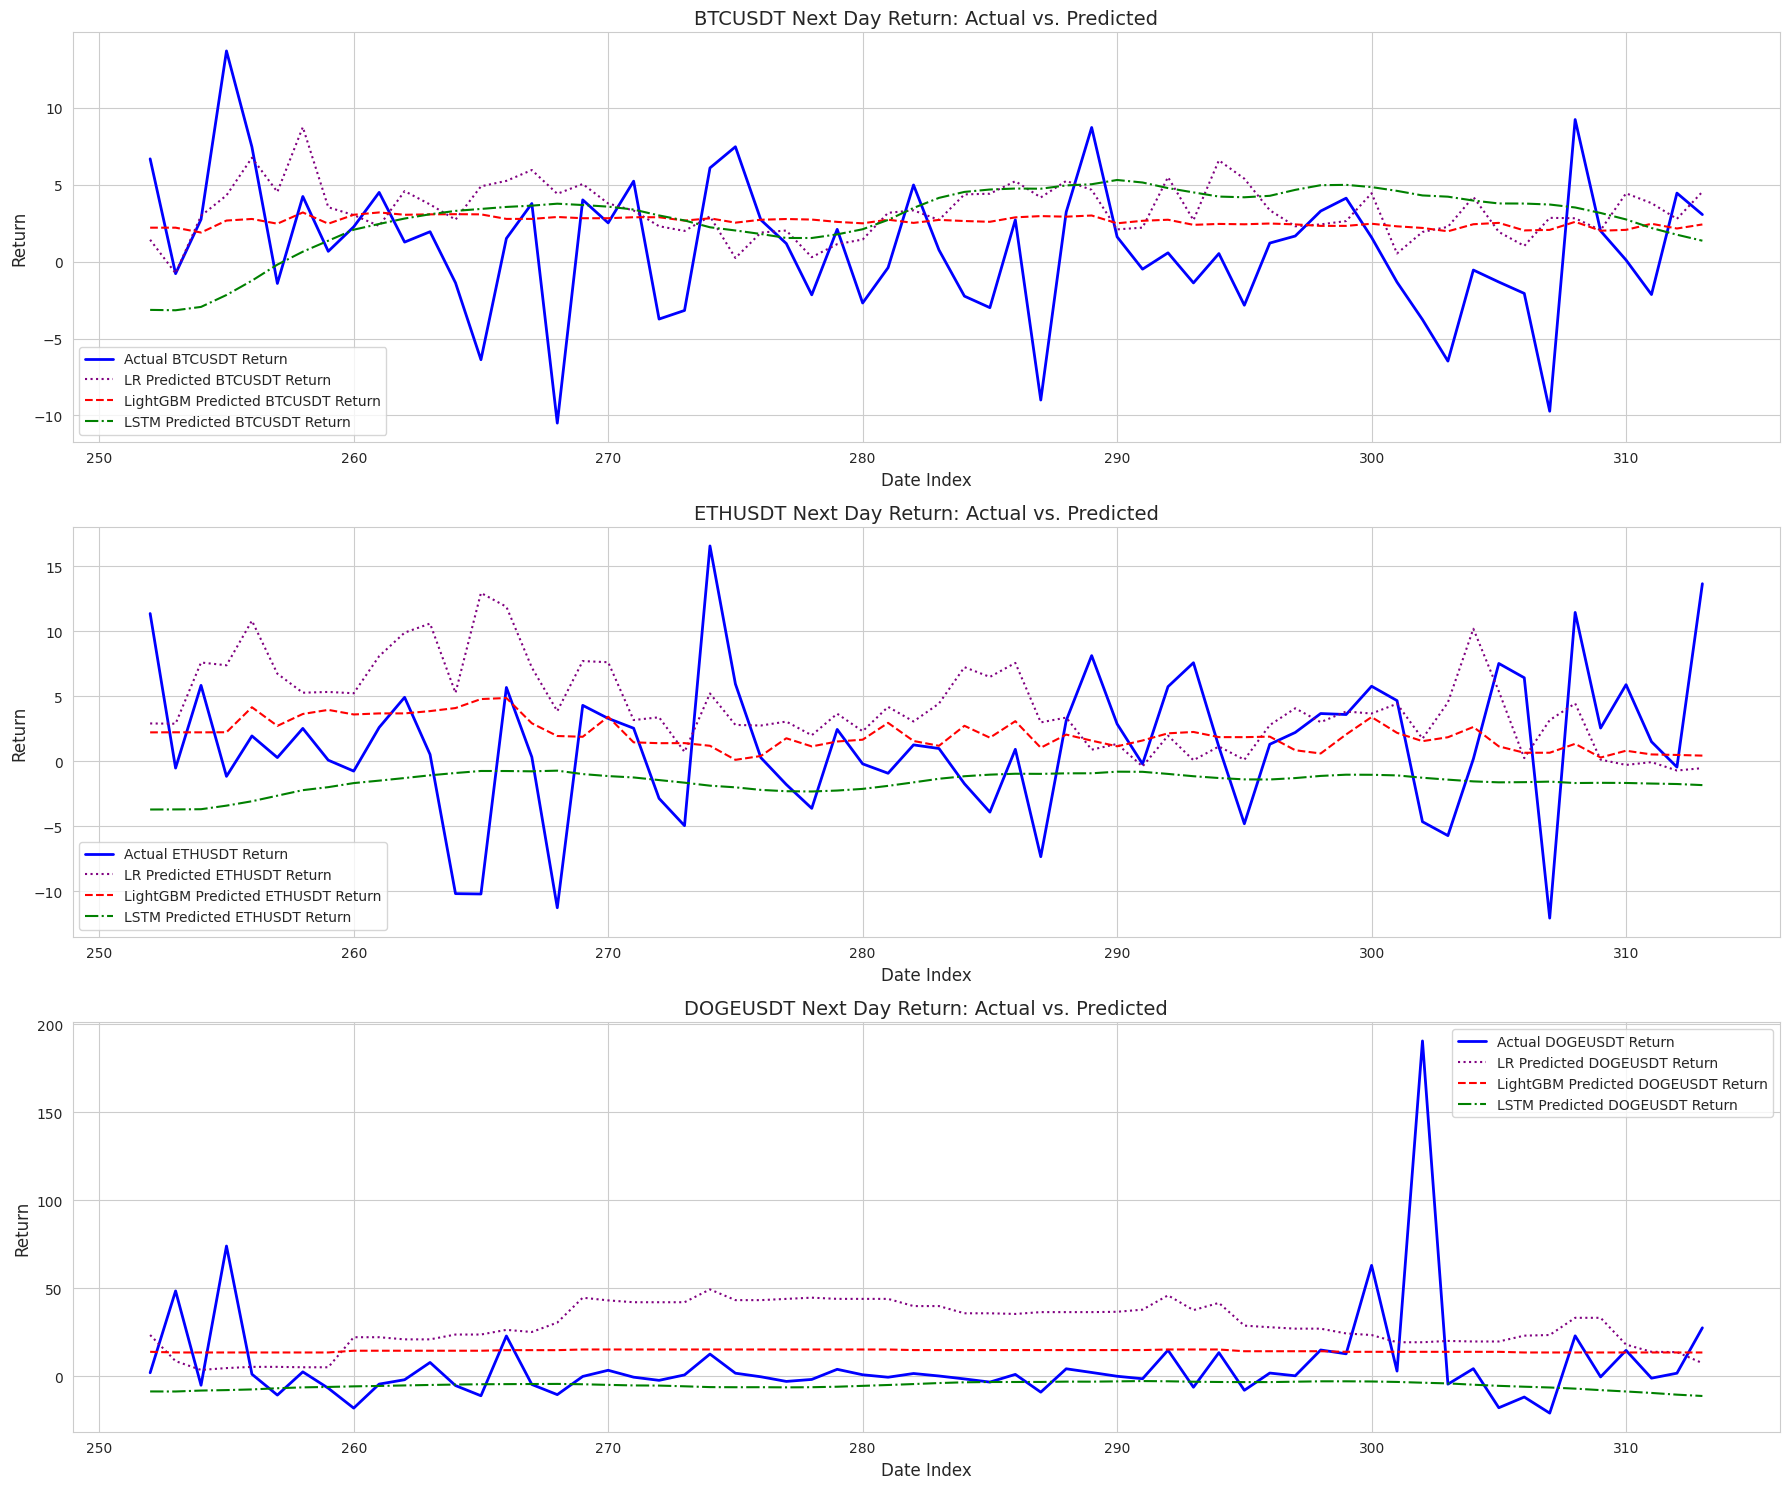

Visualizations of actual vs. predicted next day close prices generated for all models.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

plt.figure(figsize=(18, 15))

crypto_symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT"]

# Iterate through each cryptocurrency to visualize predictions
for i, symbol in enumerate(crypto_symbols):
    # --- Get Actual Test Values ---
    y_test_lr = y_test_dict[symbol]
    y_test_lgbm = y_test_dict[symbol]
    y_test_lstm = y_test_sequences[symbol]

    # --- Get Predictions from Linear Regression Model ---
    lr_model = models[symbol]
    lr_y_pred = lr_model.predict(X_test_dict[symbol])

    # --- Get Predictions from Tuned LightGBM Model ---
    best_lgbm_model = grid_search_models[symbol].best_estimator_
    lgbm_y_pred = best_lgbm_model.predict(X_test_dict[symbol])

    # --- Get Predictions from LSTM Model ---
    lstm_model = lstm_models[symbol]
    lstm_y_pred = lstm_model.predict(X_test_sequences[symbol]).flatten()

    plt.subplot(len(crypto_symbols), 1, i + 1)

    aligned_y_test_lr_index = y_test_lr.index[1:]
    aligned_y_test_lr = y_test_lr.iloc[1:]
    aligned_lr_y_pred = lr_y_pred[1:]
    aligned_lgbm_y_pred = lgbm_y_pred[1:]

    # Plot Actual Values
    plt.plot(aligned_y_test_lr_index, aligned_y_test_lr, label=f'Actual {symbol} Return', color='blue', linewidth=2)

    # Plot Linear Regression Predictions
    plt.plot(aligned_y_test_lr_index, aligned_lr_y_pred, label=f'LR Predicted {symbol} Return', color='purple', linestyle=':', linewidth=1.5)

    # Plot Tuned LightGBM Predictions
    plt.plot(aligned_y_test_lr_index, aligned_lgbm_y_pred, label=f'LightGBM Predicted {symbol} Return', color='red', linestyle='--', linewidth=1.5)

    # Plot LSTM Predictions, using the aligned index
    plt.plot(aligned_y_test_lr_index, lstm_y_pred, label=f'LSTM Predicted {symbol} Return', color='green', linestyle='-.', linewidth=1.5)

    plt.title(f'{symbol} Next Day Return: Actual vs. Predicted', fontsize=14)
    plt.xlabel('Date Index', fontsize=12)
    plt.ylabel('Return', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True)

plt.tight_layout()
plt.show()

print("Visualizations of actual vs. predicted next day close prices generated for all models.")

## Change data selection for the model

In [ ]:
from pyspark.sql.functions import col, lag
from pyspark.sql.window import Window

daily_ohlcv_with_targets = spark.read.parquet("/content/daily_data_with_targets.parquet")

crypto_symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT"]

window_spec = Window.orderBy("day")

daily_ohlcv_next_day_close = daily_ohlcv_with_targets

for symbol in crypto_symbols:
    daily_ohlcv_next_day_close = daily_ohlcv_next_day_close.withColumn(
        f"{symbol}_next_day_close",
        lag(col(f"{symbol}_close"), -1).over(window_spec)
    )

daily_ohlcv_next_day_close = daily_ohlcv_next_day_close.drop(
    "BTCUSDT_next_daily_return",
    "ETHUSDT_next_daily_return",
    "DOGEUSDT_next_daily_return"
)

daily_ohlcv_next_day_close = daily_ohlcv_next_day_close.cache()

print("Schema of daily_ohlcv_next_day_close DataFrame:")
daily_ohlcv_next_day_close.printSchema()

print("\nFirst 5 rows of daily_ohlcv_next_day_close DataFrame:")
daily_ohlcv_next_day_close.show(5, truncate=False)

output_path_next_day_close = "/content/daily_data_with_targets_next_day_close.parquet"
daily_ohlcv_next_day_close.write.mode("overwrite").parquet(output_path_next_day_close)

print(f"\nDaily DataFrame with next day close targets saved to {output_path_next_day_close} successfully.")

Schema of daily_ohlcv_next_day_close DataFrame:
root
 |-- day: timestamp (nullable = true)
 |-- BTCUSDT_open: double (nullable = true)
 |-- BTCUSDT_high: double (nullable = true)
 |-- BTCUSDT_low: double (nullable = true)
 |-- BTCUSDT_close: double (nullable = true)
 |-- BTCUSDT_volume: double (nullable = true)
 |-- ETHUSDT_open: double (nullable = true)
 |-- ETHUSDT_high: double (nullable = true)
 |-- ETHUSDT_low: double (nullable = true)
 |-- ETHUSDT_close: double (nullable = true)
 |-- ETHUSDT_volume: double (nullable = true)
 |-- DOGEUSDT_open: double (nullable = true)
 |-- DOGEUSDT_high: double (nullable = true)
 |-- DOGEUSDT_low: double (nullable = true)
 |-- DOGEUSDT_close: double (nullable = true)
 |-- DOGEUSDT_volume: double (nullable = true)
 |-- SPY_open: double (nullable = true)
 |-- SPY_high: double (nullable = true)
 |-- SPY_low: double (nullable = true)
 |-- SPY_close: double (nullable = true)
 |-- SPY_volume: double (nullable = true)
 |-- BTCUSDT_daily_close_lag1: doubl

### Clean dataset

In [ ]:
import pandas as pd

daily_ohlcv_all_lags = spark.read.parquet("/content/daily_data_final_features.parquet")

daily_ohlcv_next_day_close = spark.read.parquet("/content/daily_data_with_targets_next_day_close.parquet")

daily_data_with_new_targets = daily_ohlcv_all_lags.join(daily_ohlcv_next_day_close.select("day", "BTCUSDT_next_day_close", "ETHUSDT_next_day_close", "DOGEUSDT_next_day_close"), "day", "inner")

daily_df_pd = daily_data_with_new_targets.toPandas()

symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SPY"]

base_ohlcv_features = ["open", "high", "low", "close", "volume"]

base_return_features = ["daily_return"]

technical_indicators_to_lag = [
    "ATR", "stoch_K", "stoch_D", "OBV", "CMF", "RSI",
    "MACD_line", "MACD_signal", "MACD_hist", "BB_upper", "BB_lower"
]

feature_cols = []
for symbol in symbols:
    for base_feature in base_ohlcv_features + base_return_features:
        # Current day's feature
        feature_cols.append(f"{symbol}_{base_feature}")
        # Lagged features
        for lag_days in range(1, 8):
            feature_cols.append(f"{symbol}_{base_feature}_lag{lag_days}")

for symbol in symbols:
    for indicator in technical_indicators_to_lag:
        current_indicator_col_name = f"{symbol}_{indicator}"
        feature_cols.append(current_indicator_col_name)
        for lag_days in range(1, 8):
            feature_cols.append(f"{current_indicator_col_name}_lag{lag_days}")

target_cols = [
    "BTCUSDT_next_day_close",
    "ETHUSDT_next_day_close",
    "DOGEUSDT_next_day_close"
]

existing_feature_cols = [col for col in feature_cols if col in daily_df_pd.columns]
existing_target_cols = [col for col in target_cols if col in daily_df_pd.columns]

# Drop any rows from daily_df_pd that have NaN values in any of these columns.
daily_df_pd_cleaned = daily_df_pd.dropna(subset=existing_feature_cols + existing_target_cols).reset_index(drop=True)

print(f"Shape of the cleaned Pandas DataFrame: {daily_df_pd_cleaned.shape}")

# Display the first few rows of the cleaned DataFrame to inspect
print("\nFirst 5 rows of the cleaned Pandas DataFrame:")
print(daily_df_pd_cleaned.head())

Shape of the cleaned Pandas DataFrame: (314, 387)

First 5 rows of the cleaned Pandas DataFrame:
         day  BTCUSDT_open  BTCUSDT_high  BTCUSDT_low  BTCUSDT_close  \
0 2020-01-21       8641.80       8677.12       8602.8        8662.35   
1 2020-01-22       8789.95       8795.02       8622.0        8645.00   
2 2020-01-23       8591.46       8624.51       8333.0        8350.00   
3 2020-01-24       8310.00       8480.00       8238.0        8466.27   
4 2020-01-27       8665.49       8785.00       8535.0        8739.60   

   BTCUSDT_volume  ETHUSDT_open  ETHUSDT_high  ETHUSDT_low  ETHUSDT_close  \
0     8310.129676        166.85        169.25       165.86         168.88   
1    11890.325928        171.09        171.19       166.03         166.43   
2    19517.495363        164.93        165.69       161.08         161.61   
3    17148.994232        158.54        162.00       155.55         161.73   
4    16504.595268        167.52        170.90       165.22         169.10   

   ... 

### Train-test split cleaned dataset

In [ ]:
split_index = int(len(daily_df_pd_cleaned) * 0.8)

train_df = daily_df_pd_cleaned.iloc[:split_index]
test_df = daily_df_pd_cleaned.iloc[split_index:]

print(f"Shape of training DataFrame (train_df): {train_df.shape}")
print(f"Shape of testing DataFrame (test_df): {test_df.shape}")

Shape of training DataFrame (train_df): (251, 387)
Shape of testing DataFrame (test_df): (63, 387)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_dict = {}
X_test_dict = {}
y_train_dict = {}
y_test_dict = {}

split_ratio = 0.8

# Iterate through each target cryptocurrency (BTCUSDT, ETHUSDT, DOGEUSDT)
for target_col in target_cols:
    # Extract the cryptocurrency symbol from the target column name
    symbol = target_col.replace("_next_day_close", "")

    print(f"Preparing data for {symbol}...")

    features_for_this_model = [col_name for col_name in existing_feature_cols if col_name != 'day' and col_name not in existing_target_cols]

    # Create feature (X) and target (y) matrices
    X = daily_df_pd_cleaned[features_for_this_model]
    y = daily_df_pd_cleaned[target_col]

    # Split the data into training and testing sets (80/20 split)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=(1-split_ratio), shuffle=False, random_state=12)

    # Store the results in dictionaries
    X_train_dict[symbol] = X_train
    X_test_dict[symbol] = X_test
    y_train_dict[symbol] = y_train
    y_test_dict[symbol] = y_test

    print(f"  {symbol} - X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"  {symbol} - X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

print("\nData preparation complete for all cryptocurrencies.")

Preparing data for BTCUSDT...
  BTCUSDT - X_train shape: (251, 376), y_train shape: (251,)
  BTCUSDT - X_test shape: (63, 376), y_test shape: (63,)
Preparing data for ETHUSDT...
  ETHUSDT - X_train shape: (251, 376), y_train shape: (251,)
  ETHUSDT - X_test shape: (63, 376), y_test shape: (63,)
Preparing data for DOGEUSDT...
  DOGEUSDT - X_train shape: (251, 376), y_train shape: (251,)
  DOGEUSDT - X_test shape: (63, 376), y_test shape: (63,)

Data preparation complete for all cryptocurrencies.


### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize a dictionary to store the trained models
models = {}

# Iterate through each cryptocurrency to train a model
for symbol in X_train_dict.keys():
    print(f"Training Linear Regression model for {symbol}...")

    X_train = X_train_dict[symbol]
    y_train = y_train_dict[symbol]

    model = LinearRegression()

    model.fit(X_train, y_train)

    # Store the trained model
    models[symbol] = model
    print(f"Model for {symbol} trained successfully.")

print("\nAll models trained:", list(models.keys()))

Training Linear Regression model for BTCUSDT...
Model for BTCUSDT trained successfully.
Training Linear Regression model for ETHUSDT...
Model for ETHUSDT trained successfully.
Training Linear Regression model for DOGEUSDT...
Model for DOGEUSDT trained successfully.

All models trained: ['BTCUSDT', 'ETHUSDT', 'DOGEUSDT']


### Initialize MSE, R2, MAE

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Initialize a dictionary to store the evaluation metrics
evaluation_metrics = {}

# Iterate through each trained model
for symbol, model in models.items():
    print(f"\nEvaluating model for {symbol}...")

    # Prepare test data
    X_test = X_test_dict[symbol]
    y_test = y_test_dict[symbol]

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Calculate R-squared score
    r2 = r2_score(y_test, y_pred)

    # Calculate Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_test, y_pred)

    # Print the metrics
    print(f"  RMSE for {symbol}: {rmse:.4f}")
    print(f"  R-squared for {symbol}: {r2:.4f}")
    print(f"  MAE for {symbol}: {mae:.4f}")

    # Store the metrics
    evaluation_metrics[symbol] = {
        "RMSE": rmse,
        "R2": r2,
        "MAE": mae
    }

print("\nAll models evaluated. Evaluation metrics:")
for symbol, metrics in evaluation_metrics.items():
    print(f"  {symbol}: {metrics}")


Evaluating model for BTCUSDT...
  RMSE for BTCUSDT: 59316.3278
  R-squared for BTCUSDT: -90.9440
  MAE for BTCUSDT: 47681.1721

Evaluating model for ETHUSDT...
  RMSE for ETHUSDT: 2084.6946
  R-squared for ETHUSDT: -32.5045
  MAE for ETHUSDT: 1547.4331

Evaluating model for DOGEUSDT...
  RMSE for DOGEUSDT: 0.1492
  R-squared for DOGEUSDT: -1.0007
  MAE for DOGEUSDT: 0.1116

All models evaluated. Evaluation metrics:
  BTCUSDT: {'RMSE': np.float64(59316.327755678554), 'R2': -90.94399902843767, 'MAE': 47681.172140608214}
  ETHUSDT: {'RMSE': np.float64(2084.694558448025), 'R2': -32.50454217542511, 'MAE': 1547.4330666421838}
  DOGEUSDT: {'RMSE': np.float64(0.14923314306749766), 'R2': -1.0007185533435967, 'MAE': 0.11157518474051126}


### Set up hyperparameter grip for GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 10, 16],
    'num_leaves': [20, 31, 64],
    'subsample': [0.7, 1.0]
}

print("Hyperparameter grid defined successfully.")
print(param_grid)

Hyperparameter grid defined successfully.
{'n_estimators': [100, 200, 500, 1000], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [5, 10, 16], 'num_leaves': [20, 31, 64], 'subsample': [0.7, 1.0]}


### Get best parameters for LGBMRegressor


In [ ]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

# Initialize a dictionary to store the GridSearchCV results for each cryptocurrency
grid_search_models = {}

# Loop through each cryptocurrency symbol
for symbol in X_train_dict.keys():
    print(f"Performing Grid Search for {symbol}...")

    # Retrieve training data
    X_train = X_train_dict[symbol]
    y_train = y_train_dict[symbol]

    lgbm = LGBMRegressor(random_state=12)

    # Create a GridSearchCV object
    grid_search = GridSearchCV(
        estimator=lgbm,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=0,
        n_jobs=-1
    )

    # Fit the GridSearchCV object to the training data
    grid_search.fit(X_train, y_train)

    # Store the fitted GridSearchCV object
    grid_search_models[symbol] = grid_search

    print(f"Grid Search completed for {symbol}. Best parameters: {grid_search.best_params_}")
    print(f"Best RMSE for {symbol}: {abs(grid_search.best_score_)**0.5:.4f}")

print("\nAll Grid Search Cross-Validation completed.")

Performing Grid Search for BTCUSDT...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002897 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31827
[LightGBM] [Info] Number of data points in the train set: 251, number of used features: 376
[LightGBM] [Info] Start training from score 13334.359560
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

### Get RMSE, R2, MAE for LGBMR

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Initialize a dictionary to store the evaluation metrics for the tuned models
evaluation_metrics_tuned = {}

# Iterate through each trained GridSearchCV object
for symbol, grid_search in grid_search_models.items():
    print(f"\nEvaluating tuned model for {symbol}...")

    # Get the best estimator from GridSearchCV
    best_model = grid_search.best_estimator_

    # Prepare test data
    X_test = X_test_dict[symbol]
    y_test = y_test_dict[symbol]

    # Make predictions
    y_pred = best_model.predict(X_test)

    # Calculate Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Calculate R-squared score
    r2 = r2_score(y_test, y_pred)

    # Calculate Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_test, y_pred)

    # Print the metrics
    print(f"  RMSE for {symbol} (Tuned): {rmse:.4f}")
    print(f"  R-squared for {symbol} (Tuned): {r2:.4f}")
    print(f"  MAE for {symbol} (Tuned): {mae:.4f}")

    # Store the metrics
    evaluation_metrics_tuned[symbol] = {
        "RMSE": rmse,
        "R2": r2,
        "MAE": mae
    }

print("\nAll tuned models evaluated. Tuned Evaluation metrics:")
for symbol, metrics in evaluation_metrics_tuned.items():
    print(f"  {symbol}: {metrics}")


Evaluating tuned model for BTCUSDT...
  RMSE for BTCUSDT (Tuned): 19250.0986
  R-squared for BTCUSDT (Tuned): -8.6837
  MAE for BTCUSDT (Tuned): 18117.3622

Evaluating tuned model for ETHUSDT...
  RMSE for ETHUSDT (Tuned): 730.0145
  R-squared for ETHUSDT (Tuned): -3.1085
  MAE for ETHUSDT (Tuned): 639.9573

Evaluating tuned model for DOGEUSDT...
  RMSE for DOGEUSDT (Tuned): 0.1437
  R-squared for DOGEUSDT (Tuned): -0.8563
  MAE for DOGEUSDT (Tuned): 0.0974

All tuned models evaluated. Tuned Evaluation metrics:
  BTCUSDT: {'RMSE': np.float64(19250.098569137615), 'R2': -8.683688078025622, 'MAE': 18117.362199114075}
  ETHUSDT: {'RMSE': np.float64(730.0144690836497), 'R2': -3.108485498209168, 'MAE': 639.957303831022}
  DOGEUSDT: {'RMSE': np.float64(0.14374608912126957), 'R2': -0.8562971721479689, 'MAE': 0.09744272979377523}


### Scale with MinMax

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

X = daily_df_pd_cleaned[existing_feature_cols]

X_scaled = scaler.fit_transform(X)

look_back_window = 7

X_sequences = {}
y_sequences = {}
y_targets = {}

for target_col in target_cols:
    symbol = target_col.replace("_next_day_close", "")
    print(f"Processing sequences for {symbol}...")

    X_seq_list = []
    y_seq_list = []

    y_data = daily_df_pd_cleaned[target_col].values

    for i in range(look_back_window, len(daily_df_pd_cleaned)):

        X_seq_list.append(X_scaled[i - look_back_window:i])

        y_seq_list.append(y_data[i])

    X_sequences[symbol] = np.array(X_seq_list)
    y_sequences[symbol] = np.array(y_seq_list)

    y_targets[symbol] = y_data[look_back_window:]

# Print the shapes of the generated X_sequences, y_sequences, and y_targets for each symbol to verify their dimensions.
print("\nShape of generated sequences and targets:")
for symbol in X_sequences.keys():
    print(f"  {symbol} - X_sequences shape: {X_sequences[symbol].shape}")
    print(f"  {symbol} - y_sequences shape: {y_sequences[symbol].shape}")
    print(f"  {symbol} - y_targets shape: {y_targets[symbol].shape}")

Processing sequences for BTCUSDT...
Processing sequences for ETHUSDT...
Processing sequences for DOGEUSDT...

Shape of generated sequences and targets:
  BTCUSDT - X_sequences shape: (307, 7, 376)
  BTCUSDT - y_sequences shape: (307,)
  BTCUSDT - y_targets shape: (307,)
  ETHUSDT - X_sequences shape: (307, 7, 376)
  ETHUSDT - y_sequences shape: (307,)
  ETHUSDT - y_targets shape: (307,)
  DOGEUSDT - X_sequences shape: (307, 7, 376)
  DOGEUSDT - y_sequences shape: (307,)
  DOGEUSDT - y_targets shape: (307,)


In [ ]:
split_ratio = 0.8

X_train_sequences = {}
X_test_sequences = {}
y_train_sequences = {}
y_test_sequences = {}

for symbol in X_sequences.keys():
    print(f"Splitting data for {symbol}...")

    # Determine the split index
    split_index = int(len(X_sequences[symbol]) * split_ratio)

    # Split X sequences
    X_train_sequences[symbol] = X_sequences[symbol][:split_index]
    X_test_sequences[symbol] = X_sequences[symbol][split_index:]

    # Split y sequences
    y_train_sequences[symbol] = y_sequences[symbol][:split_index]
    y_test_sequences[symbol] = y_sequences[symbol][split_index:]

    print(f"  {symbol} - X_train_sequences shape: {X_train_sequences[symbol].shape}")
    print(f"  {symbol} - y_train_sequences shape: {y_train_sequences[symbol].shape}")
    print(f"  {symbol} - X_test_sequences shape: {X_test_sequences[symbol].shape}")
    print(f"  {symbol} - y_test_sequences shape: {y_test_sequences[symbol].shape}")

print("\nSequential data split complete for all cryptocurrencies.")

Splitting data for BTCUSDT...
  BTCUSDT - X_train_sequences shape: (245, 7, 376)
  BTCUSDT - y_train_sequences shape: (245,)
  BTCUSDT - X_test_sequences shape: (62, 7, 376)
  BTCUSDT - y_test_sequences shape: (62,)
Splitting data for ETHUSDT...
  ETHUSDT - X_train_sequences shape: (245, 7, 376)
  ETHUSDT - y_train_sequences shape: (245,)
  ETHUSDT - X_test_sequences shape: (62, 7, 376)
  ETHUSDT - y_test_sequences shape: (62,)
Splitting data for DOGEUSDT...
  DOGEUSDT - X_train_sequences shape: (245, 7, 376)
  DOGEUSDT - y_train_sequences shape: (245,)
  DOGEUSDT - X_test_sequences shape: (62, 7, 376)
  DOGEUSDT - y_test_sequences shape: (62,)

Sequential data split complete for all cryptocurrencies.


### TensorFlow: Set up LTSM layers

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

lstm_models = {}

for symbol in X_train_sequences.keys():
    print(f"Defining and compiling LSTM model for {symbol}...")

    num_features = X_train_sequences[symbol].shape[2]
    input_shape = (look_back_window, num_features)

    # Create a Sequential Keras model
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units=100, activation='relu', return_sequences=False),
        Dropout(0.2),
        Dense(units=1)
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

    # Store the compiled model in the dictionary
    lstm_models[symbol] = model

    print(f"Model for {symbol} compiled successfully.")
    model.summary()

print("\nAll LSTM models have been defined and compiled. Models for:", list(lstm_models.keys()))

Defining and compiling LSTM model for BTCUSDT...
Model for BTCUSDT compiled successfully.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100)            │       190,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,901 (745.71 KB)

 Trainable params: 190,901 (745.71 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 100)            │       190,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,901 (745.71 KB)

 Trainable params: 190,901 (745.71 KB)

 Non-trainable params: 0 (0.00 B)


All LSTM models have been defined and compiled. Models for: ['BTCUSDT', 'ETHUSDT', 'DOGEUSDT']


### Fit the model

In [ ]:
history = {}

# Iterate through each cryptocurrency symbol and its compiled LSTM model
for symbol, model in lstm_models.items():
    print(f"\nTraining LSTM model for {symbol}...")

    # Retrieve training data for the current symbol
    X_train = X_train_sequences[symbol]
    y_train = y_train_sequences[symbol]

    # Train the LSTM model
    hist = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )
    history[symbol] = hist

    print(f"LSTM model for {symbol} trained successfully.")

print("\nAll LSTM models have been trained.")


Training LSTM model for BTCUSDT...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 108057856.0000 - mean_absolute_error: 10201.7539 - val_loss: 773287168.0000 - val_mean_absolute_error: 26807.8320
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 106798640.0000 - mean_absolute_error: 10096.7285 - val_loss: 758330240.0000 - val_mean_absolute_error: 26531.1738
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 105931096.0000 - mean_absolute_error: 10053.8857 - val_loss: 699713216.0000 - val_mean_absolute_error: 25415.4492
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 86740784.0000 - mean_absolute_error: 9030.4473 - val_loss: 502544928.0000 - val_mean_absolute_error: 21232.9238
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 30753732.0000 - mean_absolute_error: 4955.7012 - val_loss: 115371224.0000 - val_mean_absolute_error: 8370.3975
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 18566456.0000 - mean_absolute_error: 3605.7905 - val_loss

### Get MSE, R2, MAE

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Initialize a dictionary to store the evaluation metrics for the LSTM models
lstm_evaluation_metrics = {}

# Iterate through each trained LSTM model
for symbol, model in lstm_models.items():
    print(f"\nEvaluating LSTM model for {symbol}...")

    # Prepare test data
    X_test = X_test_sequences[symbol]
    y_test = y_test_sequences[symbol]

    # Make predictions
    y_pred = model.predict(X_test)

    # Flatten y_pred as it comes out as a 2D array (samples, 1)
    y_pred_flat = y_pred.flatten()

    # Calculate Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_flat))

    # Calculate R-squared score
    r2 = r2_score(y_test, y_pred_flat)

    # Calculate Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_test, y_pred_flat)

    # Print the metrics
    print(f"  RMSE for {symbol} (LSTM): {rmse:.4f}")
    print(f"  R-squared for {symbol} (LSTM): {r2:.4f}")
    print(f"  MAE for {symbol} (LSTM): {mae:.4f}")

    # Store the metrics
    lstm_evaluation_metrics[symbol] = {
        "RMSE": rmse,
        "R2": r2,
        "MAE": mae
    }

print("\nAll LSTM models evaluated. Evaluation metrics:")
for symbol, metrics in lstm_evaluation_metrics.items():
    print(f"  {symbol}: {metrics}")


Evaluating LSTM model for BTCUSDT...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
  RMSE for BTCUSDT (LSTM): 26745.9001
  R-squared for BTCUSDT (LSTM): -20.3921
  MAE for BTCUSDT (LSTM): 26440.3450

Evaluating LSTM model for ETHUSDT...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
  RMSE for ETHUSDT (LSTM): 901.9459
  R-squared for ETHUSDT (LSTM): -5.3416
  MAE for ETHUSDT (LSTM): 849.6161

Evaluating LSTM model for DOGEUSDT...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
  RMSE for DOGEUSDT (LSTM): 0.1513
  R-squared for DOGEUSDT (LSTM): -1.0422
  MAE for DOGEUSDT (LSTM): 0.1094

All LSTM models evaluated. Evaluation metrics:
  BTCUSDT: {'RMSE': np.float64(26745.90005680004), 'R2': -20.392143269591028, 'MAE': 26440.345011340727}
  ETHUSDT: {'RMSE': np.float64(901.9458540310376), 'R2': -5.341611536258172, 'MAE': 849.6161256064138}
  DOGEUSDT: {'RMSE': np.float64(0.15132188342496677), 'R2': -1.042242460309033, 'MAE': 0.10940702424707581}


#### LightGBM MSE, R2, MAE

In [ ]:
print("Tuned LightGBM Evaluation metrics:")
for symbol, metrics in evaluation_metrics_tuned.items():
    print(f"  {symbol}: {metrics}")

Tuned LightGBM Evaluation metrics:
  BTCUSDT: {'RMSE': np.float64(19250.098569137615), 'R2': -8.683688078025622, 'MAE': 18117.362199114075}
  ETHUSDT: {'RMSE': np.float64(730.0144690836497), 'R2': -3.108485498209168, 'MAE': 639.957303831022}
  DOGEUSDT: {'RMSE': np.float64(0.14374608912126957), 'R2': -0.8562971721479689, 'MAE': 0.09744272979377523}


#### LSTM MSE, R2, MAE

In [ ]:
print("\nLSTM Evaluation metrics:")
for symbol, metrics in lstm_evaluation_metrics.items():
    print(f"  {symbol}: {metrics}")


LSTM Evaluation metrics:
  BTCUSDT: {'RMSE': np.float64(26745.90005680004), 'R2': -20.392143269591028, 'MAE': 26440.345011340727}
  ETHUSDT: {'RMSE': np.float64(901.9458540310376), 'R2': -5.341611536258172, 'MAE': 849.6161256064138}
  DOGEUSDT: {'RMSE': np.float64(0.15132188342496677), 'R2': -1.042242460309033, 'MAE': 0.10940702424707581}


### Plot model performance

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


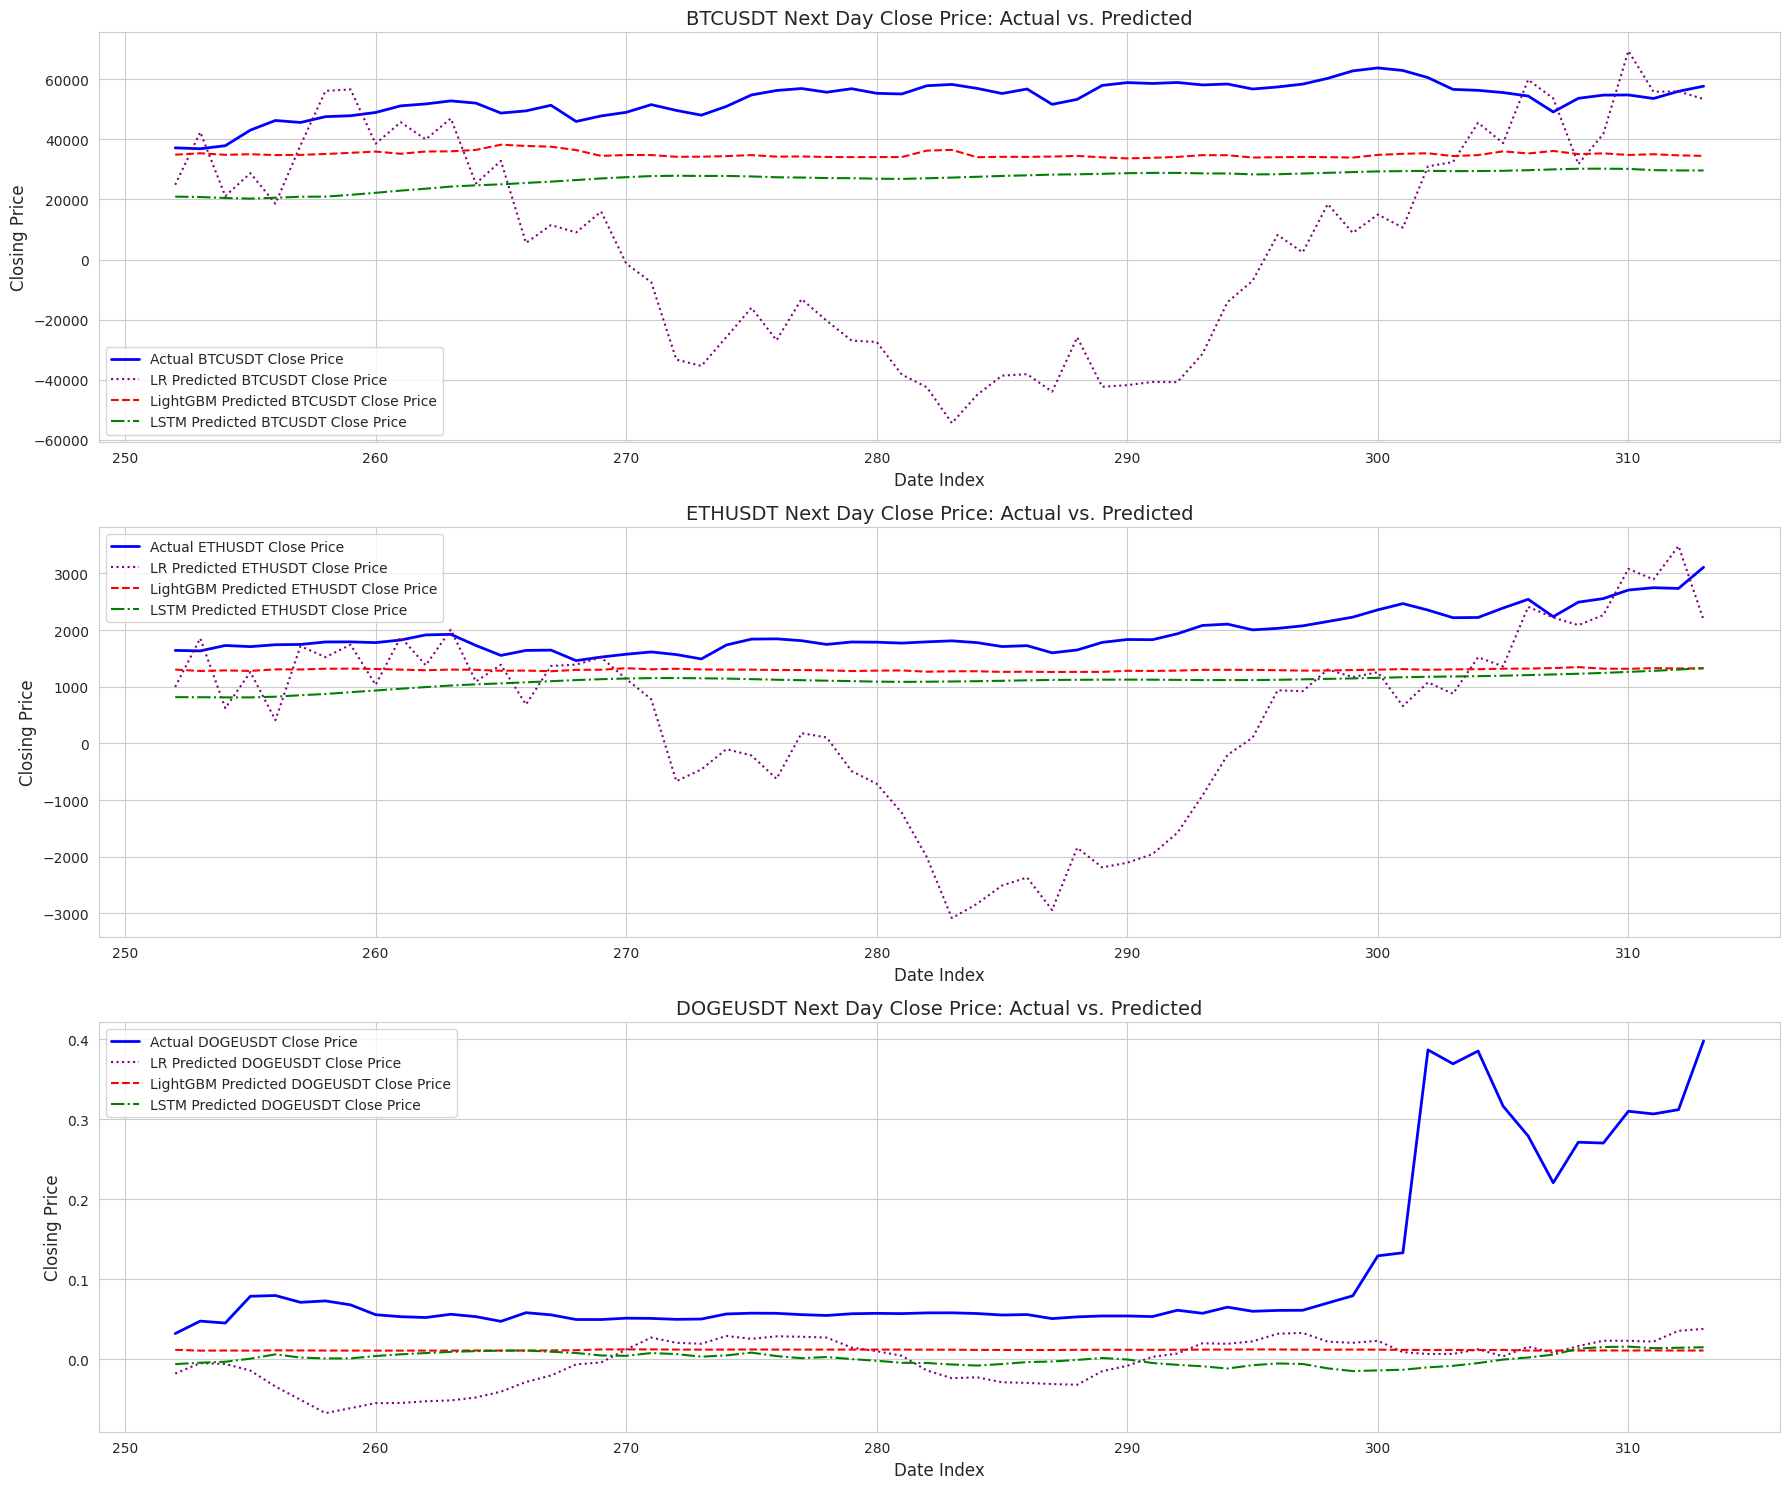

Visualizations of actual vs. predicted next day close prices generated for all models.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting style
sns.set_style("whitegrid")

# Create a figure to hold all plots
plt.figure(figsize=(18, 15))

# Define the list of cryptocurrency symbols
crypto_symbols = ["BTCUSDT", "ETHUSDT", "DOGEUSDT"]

for i, symbol in enumerate(crypto_symbols):
    y_test_lr = y_test_dict[symbol]
    y_test_lgbm = y_test_dict[symbol]
    y_test_lstm = y_test_sequences[symbol]

    # --- Get Predictions from Linear Regression Model ---
    lr_model = models[symbol]
    lr_y_pred = lr_model.predict(X_test_dict[symbol])

    # --- Get Predictions from Tuned LightGBM Model ---
    best_lgbm_model = grid_search_models[symbol].best_estimator_
    lgbm_y_pred = best_lgbm_model.predict(X_test_dict[symbol])

    # --- Get Predictions from LSTM Model ---
    lstm_model = lstm_models[symbol]
    lstm_y_pred = lstm_model.predict(X_test_sequences[symbol]).flatten()

    # Create subplot for the current symbol
    plt.subplot(len(crypto_symbols), 1, i + 1)

    num_lstm_test_samples = len(lstm_y_pred)

    aligned_y_test_lr_index = y_test_lr.index[-num_lstm_test_samples:]
    aligned_y_test_lr = y_test_lr.iloc[-num_lstm_test_samples:]
    aligned_lr_y_pred = lr_y_pred[-num_lstm_test_samples:]
    aligned_lgbm_y_pred = lgbm_y_pred[-num_lstm_test_samples:]

    # Plot Actual Values
    plt.plot(aligned_y_test_lr_index, aligned_y_test_lr, label=f'Actual {symbol} Close Price', color='blue', linewidth=2)

    # Plot Linear Regression Predictions
    plt.plot(aligned_y_test_lr_index, aligned_lr_y_pred, label=f'LR Predicted {symbol} Close Price', color='purple', linestyle=':', linewidth=1.5)

    # Plot Tuned LightGBM Predictions
    plt.plot(aligned_y_test_lr_index, aligned_lgbm_y_pred, label=f'LightGBM Predicted {symbol} Close Price', color='red', linestyle='--', linewidth=1.5)

    # Plot LSTM Predictions, using the aligned index
    plt.plot(aligned_y_test_lr_index, lstm_y_pred, label=f'LSTM Predicted {symbol} Close Price', color='green', linestyle='-.', linewidth=1.5)

    plt.title(f'{symbol} Next Day Close Price: Actual vs. Predicted', fontsize=14)
    plt.xlabel('Date Index', fontsize=12)
    plt.ylabel('Closing Price', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True)

plt.tight_layout()
plt.show()

print("Visualizations of actual vs. predicted next day close prices generated for all models.")